Autores: Josep Pérez Segura, Raul Rodríguez López Rey
# Tarea B3-T1


## 1. Importación de datos

Descargamos datos históricos de **BTCUSDT** (Bitcoin vs USDT) desde la API pública de Binance.

- **Intervalo**: velas de 5 minutos
- **Periodo**: últimos 3 años (marzo 2023 – marzo 2026)
- **Endpoint**: `GET /api/v3/klines` (sin API key, máximo 1000 velas por request)
- **Cache**: los datos se guardan en CSV local (`data/BTCUSDT_5m_3y.csv`) para no re-descargar en ejecuciones posteriores

Referencia: Lopez de Prado (2018), *Advances in Financial Machine Learning* – recomienda usar datos de alta frecuencia para construir barras alternativas (dollar bars, volume bars, tick bars).

In [1]:
%pip install requests pandas numpy matplotlib tqdm ipywidgets --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import datetime
import time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


pd.set_option("display.max_columns", None)

In [3]:
# --- Configuración ---
SYMBOLS = ["BTCUSDT", "ETHUSDT", "DOGEUSDT"]
INTERVAL = "5m"
BASE_URL = "https://api.binance.com/api/v3/klines"

START_DATE = datetime.datetime(2023, 3, 16)
END_DATE = datetime.datetime(2026, 3, 16)
START_MS = int(START_DATE.timestamp() * 1000)
END_MS = int(END_DATE.timestamp() * 1000)

LIMIT = 1000  # máximo por request
SLEEP_BETWEEN = 0.05  # evitar rate limiting

DATA_DIR = Path("data")

print(f"Periodo: {START_DATE.date()} -> {END_DATE.date()}")
print(f"Intervalo: {INTERVAL}")
print(f"Requests estimados por activo: ~{(END_MS - START_MS) // (LIMIT * 5 * 60 * 1000) + 1}")


Periodo: 2023-03-16 -> 2026-03-16
Intervalo: 5m
Requests estimados por activo: ~316


In [4]:
def fetch_klines(symbol, interval, start_ms, end_ms, limit=1000):
    """Descarga velas de Binance con paginación automática."""
    session = requests.Session()
    all_klines = []
    current_ms = start_ms

    # Estimar número de requests para la barra de progreso
    interval_ms = 5 * 60 * 1000  # 5 minutos en ms
    estimated_requests = (end_ms - start_ms) // (limit * interval_ms) + 1

    pbar = tqdm(total=estimated_requests, desc="Descargando velas")

    while current_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ms,
            "endTime": end_ms,
            "limit": limit,
        }

        resp = session.get(BASE_URL, params=params)

        # Manejo de rate limiting
        if resp.status_code in (429, 418):
            retry_after = int(resp.headers.get("Retry-After", 5))
            print(f"Rate limited. Esperando {retry_after}s...")
            time.sleep(retry_after)
            continue

        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_klines.extend(data)

        # Avanzar: close_time del último registro + 1 ms
        current_ms = data[-1][6] + 1
        pbar.update(1)

        time.sleep(SLEEP_BETWEEN)

    pbar.close()
    print(f"Total velas descargadas: {len(all_klines):,}")
    return all_klines

In [5]:
dfs = {}
for symbol in SYMBOLS:
    csv_path = DATA_DIR / f"{symbol}_{INTERVAL}_3y.csv"
    if csv_path.exists():
        print(f"Cargando datos de {symbol} desde local: {csv_path}")
        df_sym = pd.read_csv(csv_path, parse_dates=["open_time", "close_time"])
    else:
        DATA_DIR.mkdir(exist_ok=True)
        print(f"Descargando datos de {symbol}...")
        raw = fetch_klines(symbol, INTERVAL, START_MS, END_MS, LIMIT)
        
        columns = [
            "open_time", "open", "high", "low", "close", "volume",
            "close_time", "quote_volume", "num_trades",
            "taker_buy_base_vol", "taker_buy_quote_vol", "ignore",
        ]
        df_sym = pd.DataFrame(raw, columns=columns)
        
        numeric_cols = ["open", "high", "low", "close", "volume",
                        "quote_volume", "taker_buy_base_vol", "taker_buy_quote_vol"]
        df_sym[numeric_cols] = df_sym[numeric_cols].astype(float)
        df_sym["num_trades"] = df_sym["num_trades"].astype(int)
        df_sym["open_time"] = pd.to_datetime(df_sym["open_time"], unit="ms")
        df_sym["close_time"] = pd.to_datetime(df_sym["close_time"], unit="ms")
        df_sym.drop(columns=["ignore"], inplace=True)
        
        df_sym.drop_duplicates(subset=["open_time"], inplace=True)
        df_sym.sort_values("open_time", inplace=True)
        df_sym.reset_index(drop=True, inplace=True)
        
        df_sym = df_sym[(df_sym["open_time"] >= str(START_DATE)) & (df_sym["open_time"] < str(END_DATE))]
        df_sym.reset_index(drop=True, inplace=True)
        
        df_sym.to_csv(csv_path, index=False)
        
    dfs[symbol] = df_sym
    print(f"{symbol} cargado: {df_sym.shape[0]:,} filas")

df = dfs["BTCUSDT"]


Cargando datos de BTCUSDT desde local: data\BTCUSDT_5m_3y.csv
BTCUSDT cargado: 315,621 filas
Cargando datos de ETHUSDT desde local: data\ETHUSDT_5m_3y.csv
ETHUSDT cargado: 315,621 filas
Cargando datos de DOGEUSDT desde local: data\DOGEUSDT_5m_3y.csv
DOGEUSDT cargado: 315,621 filas


In [6]:
# --- Verificación y exploración ---
print(f"Periodo: {df['open_time'].min()} -> {df['open_time'].max()}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Shape: {df.shape}\n")

display(df.describe())
print()
display(df.head())

# Comprobar huecos temporales
deltas = df["open_time"].diff().dt.total_seconds().dropna()
gaps = deltas[deltas != 300]  # 300s = 5 min
print(f"\nHuecos temporales (intervalos != 5 min): {len(gaps)} de {len(deltas)}")
if len(gaps) > 0:
    print("Distribución de huecos (segundos):")
    display(gaps.value_counts().head(10))

Periodo: 2023-03-16 00:00:00 -> 2026-03-15 23:00:00
Memoria: 27.8 MB
Shape: (315621, 11)



,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
count,315621,315621.000000,315621.000000,315621.000000,315621.000000,315621.000000,315621,3.156210e+05,315621.000000,315621.000000,3.156210e+05
mean,2024-09-14 00:09:22.648872448,69255.541521,69313.958161,69195.897637,69255.695029,115.645287,2024-09-14 00:14:22.647815936,6.870378e+06,9905.474449,56.840639,3.369067e+06
min,2023-03-16 00:00:00,24137.270000,24236.990000,24123.000000,24135.210000,0.000000,2023-03-16 00:04:59.999000,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,2023-12-15 00:45:00,41715.350000,41742.450000,41691.100000,41715.740000,33.691160,2023-12-15 00:49:59.999000064,2.087278e+06,2925.000000,14.762420,9.225653e+05
50%,2024-09-14 00:10:00,67511.510000,67581.100000,67441.250000,67511.970000,63.345200,2024-09-14 00:14:59.999000064,3.883182e+06,5652.000000,29.759390,1.815473e+06
75%,2025-06-14 23:35:00,95587.300000,95677.940000,95500.000000,95587.300000,123.017120,2025-06-14 23:39:59.999000064,7.585146e+06,11731.000000,60.573720,3.720478e+06
max,2026-03-15 23:00:00,126011.180000,126199.630000,125868.130000,126011.180000,9082.013470,2026-03-15 23:04:59.999000,5.588519e+08,711259.000000,4199.910420,2.663202e+08
std,NaN,29800.183396,29822.074886,29777.898507,29800.076017,207.730483,NaN,1.040135e+07,12382.882283,105.927382,5.361188e+06


,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
0,2023-03-16 00:00:00,24285.66,24330.00,24244.85,24320.43,1297.15515,2023-03-16 00:04:59.999,3.150841e+07,37888,703.57672,1.709184e+07
1,2023-03-16 00:05:00,24319.86,24324.99,24261.40,24267.11,1031.22185,2023-03-16 00:09:59.999,2.505415e+07,31881,494.99527,1.202650e+07
2,2023-03-16 00:10:00,24267.11,24276.87,24200.00,24275.30,2103.30631,2023-03-16 00:14:59.999,5.096738e+07,46576,983.26865,2.382859e+07
3,2023-03-16 00:15:00,24275.30,24337.49,24275.21,24327.09,1143.01401,2023-03-16 00:19:59.999,2.778655e+07,32854,609.75281,1.482329e+07
4,2023-03-16 00:20:00,24327.09,24384.12,24326.14,24362.41,1363.56637,2023-03-16 00:24:59.999,3.321088e+07,36718,738.49945,1.798709e+07



Huecos temporales (intervalos != 5 min): 1 de 315620
Distribución de huecos (segundos):


open_time
5100.0    1
Name: count, dtype: int64

## 2. Barras alternativas: Dollar Bars, Volume Bars y Tick Bars

Las barras basadas en tiempo (time bars) presentan propiedades estadísticas indeseables: autocorrelación, heterocedasticidad y distribuciones no normales. Lopez de Prado (2018, Cap. 2) propone muestrear los datos usando **barras alternativas** que se cierran al alcanzar un umbral acumulado:

- **Tick Bars**: se cierra una barra cada N operaciones (trades). Muestrean según la actividad del mercado.
- **Volume Bars**: se cierra una barra cada V unidades de volumen (BTC). Normalizan la información por volumen negociado.
- **Dollar Bars**: se cierra una barra cada D dólares negociados (quote volume en USDT). Son las más robustas según MLdP, ya que normalizan por valor económico real.

Al usar velas de 5 min como proxy, cada vela aporta: `num_trades` (ticks), `volume` (BTC), y `quote_volume` (USDT). Acumulamos estos valores y generamos una nueva barra OHLCV cada vez que se supera el umbral.

Compararemos **3 umbrales distintos** para cada tipo de barra para ilustrar el efecto del parámetro.

In [7]:
def make_bars(df, metric_col, threshold):
    """
    Genera barras alternativas agrupando filas hasta que la suma acumulada
    de `metric_col` supera `threshold`.

    Parámetros:
        df: DataFrame con columnas open_time, open, high, low, close, volume,
            quote_volume, num_trades y la columna `metric_col`.
        metric_col: columna a acumular ('num_trades', 'volume', 'quote_volume').
        threshold: valor umbral para cerrar cada barra.

    Retorna:
        DataFrame con barras OHLCV + timestamp.
    """
    bars = []
    cum_metric = 0.0
    open_price = df.iloc[0]["open"]
    high_price = -np.inf
    low_price = np.inf
    cum_volume = 0.0
    cum_quote_volume = 0.0
    cum_trades = 0
    bar_start = df.iloc[0]["open_time"]

    for _, row in df.iterrows():
        high_price = max(high_price, row["high"])
        low_price = min(low_price, row["low"])
        cum_volume += row["volume"]
        cum_quote_volume += row["quote_volume"]
        cum_trades += row["num_trades"]
        cum_metric += row[metric_col]

        if cum_metric >= threshold:
            bars.append({
                "open_time": bar_start,
                "close_time": row["close_time"],
                "open": open_price,
                "high": high_price,
                "low": low_price,
                "close": row["close"],
                "volume": cum_volume,
                "quote_volume": cum_quote_volume,
                "num_trades": cum_trades,
            })
            # Reset
            cum_metric = 0.0
            cum_volume = 0.0
            cum_quote_volume = 0.0
            cum_trades = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = row["close"]
            bar_start = row["close_time"]

    return pd.DataFrame(bars)

In [8]:
# --- Calcular estadísticas para elegir umbrales razonables ---
print("Estadísticas por vela de 5 min:")
print(f"  num_trades  -> media: {df['num_trades'].mean():,.0f}, mediana: {df['num_trades'].median():,.0f}")
print(f"  volume (BTC)-> media: {df['volume'].mean():,.1f}, mediana: {df['volume'].median():,.1f}")
print(f"  quote_vol ($)-> media: {df['quote_volume'].mean():,.0f}, mediana: {df['quote_volume'].median():,.0f}")

# Umbrales: elegidos para generar ~5K, ~15K y ~50K barras aprox.
total_trades = df["num_trades"].sum()
total_volume = df["volume"].sum()
total_dollar = df["quote_volume"].sum()

tick_thresholds = [
    int(total_trades / 50_000),
    int(total_trades / 15_000),
    int(total_trades / 5_000),
]
volume_thresholds = [
    round(total_volume / 50_000, 0),
    round(total_volume / 15_000, 0),
    round(total_volume / 5_000, 0),
]
dollar_thresholds = [
    round(total_dollar / 50_000, -3),
    round(total_dollar / 15_000, -3),
    round(total_dollar / 5_000, -3),
]

print(f"\nUmbrales Tick Bars:   {tick_thresholds} trades")
print(f"Umbrales Volume Bars: {volume_thresholds} BTC")
print(f"Umbrales Dollar Bars: {dollar_thresholds} USDT")

Estadísticas por vela de 5 min:
  num_trades  -> media: 9,905, mediana: 5,652
  volume (BTC)-> media: 115.6, mediana: 63.3
  quote_vol ($)-> media: 6,870,378, mediana: 3,883,182

Umbrales Tick Bars:   [62527, 208425, 625275] trades
Umbrales Volume Bars: [np.float64(730.0), np.float64(2433.0), np.float64(7300.0)] BTC
Umbrales Dollar Bars: [np.float64(43369000.0), np.float64(144562000.0), np.float64(433687000.0)] USDT


In [9]:
# --- Generar las barras alternativas ---
print("Generando barras... (puede tardar unos segundos por cada umbral)\n")

bar_results = {}

for label, col, thresholds in [
    ("Tick Bars", "num_trades", tick_thresholds),
    ("Volume Bars", "volume", volume_thresholds),
    ("Dollar Bars", "quote_volume", dollar_thresholds),
]:
    bar_results[label] = {}
    for th in thresholds:
        bars_df = make_bars(df, col, th)
        bar_results[label][th] = bars_df
        print(f"  {label} (umbral={th:,.0f}): {len(bars_df):,} barras")
    print()

Generando barras... (puede tardar unos segundos por cada umbral)

  Tick Bars (umbral=62,527): 42,504 barras
  Tick Bars (umbral=208,425): 14,172 barras
  Tick Bars (umbral=625,275): 4,901 barras

  Volume Bars (umbral=730): 40,285 barras
  Volume Bars (umbral=2,433): 13,803 barras
  Volume Bars (umbral=7,300): 4,845 barras

  Dollar Bars (umbral=43,369,000): 41,354 barras
  Dollar Bars (umbral=144,562,000): 13,994 barras
  Dollar Bars (umbral=433,687,000): 4,878 barras



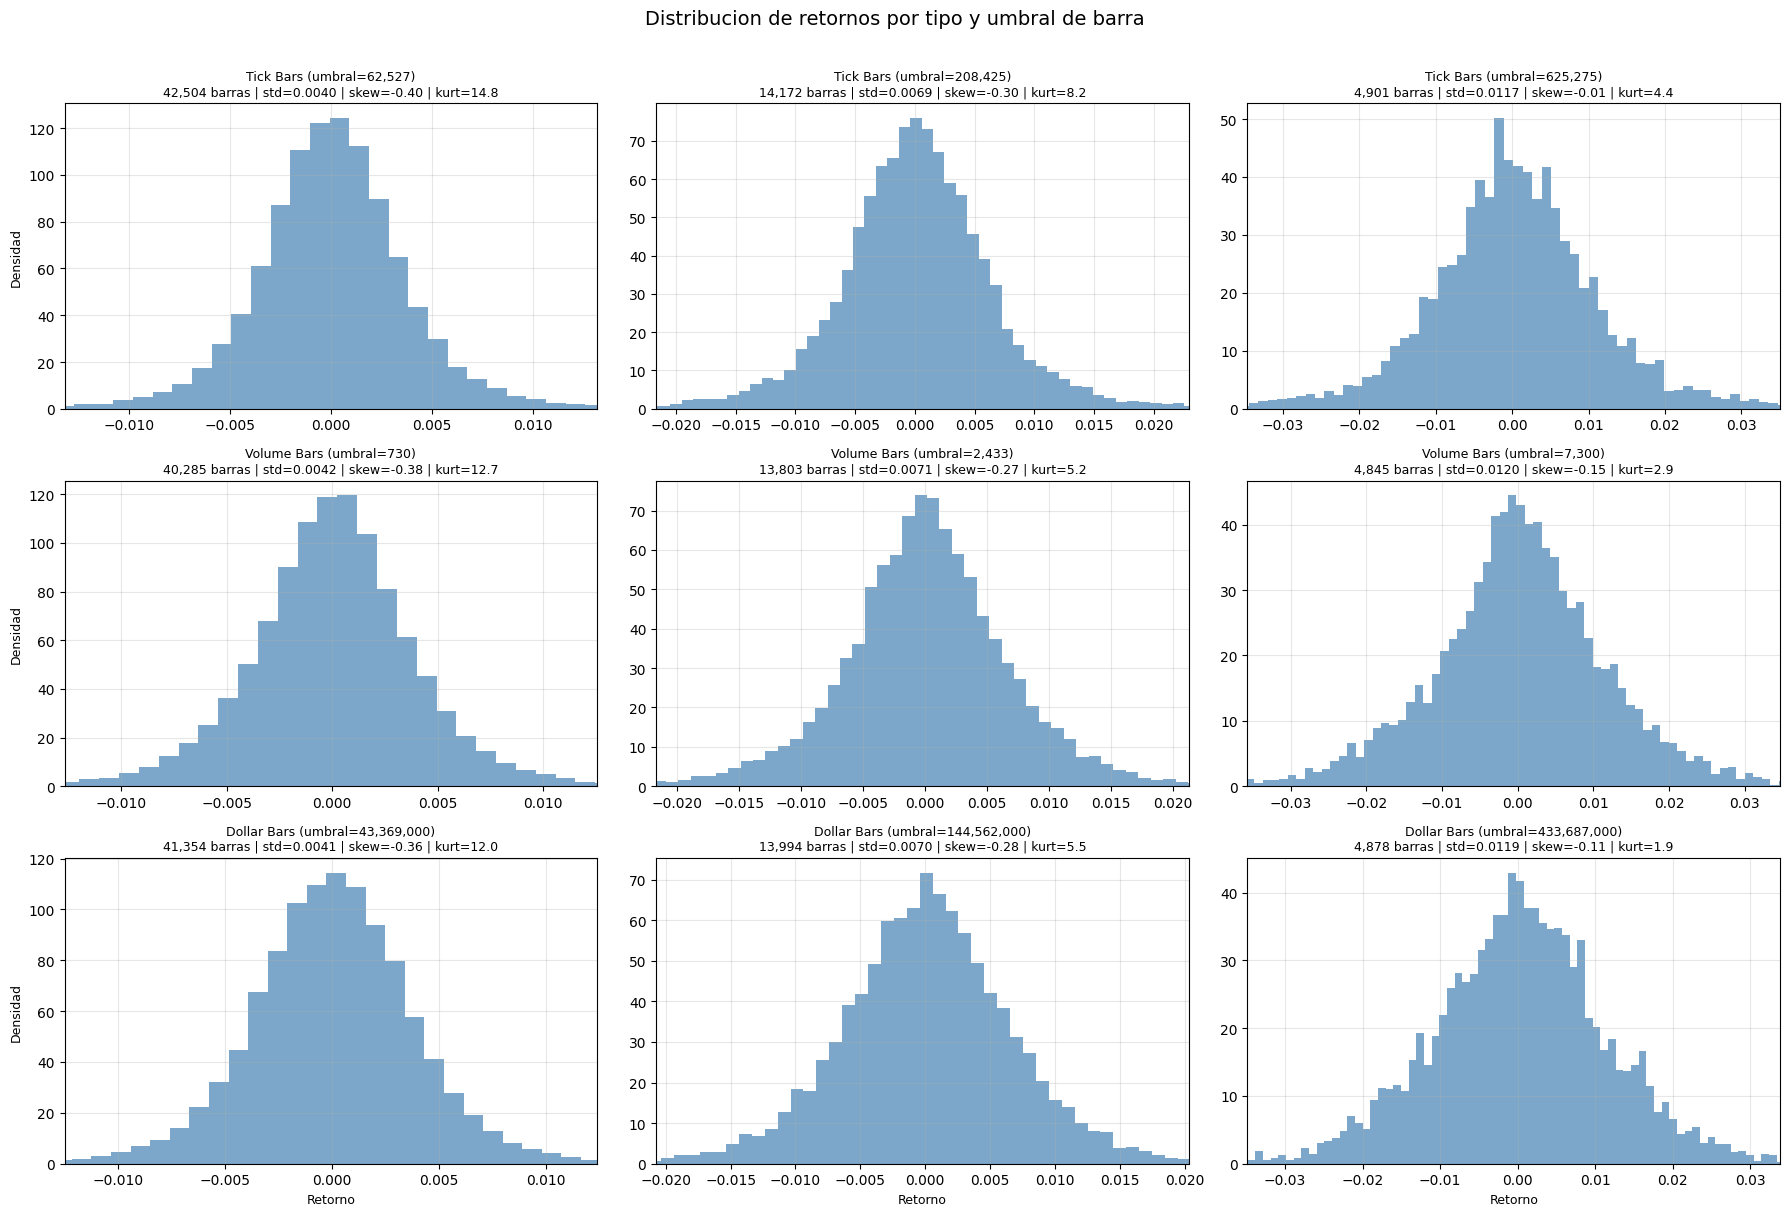

Resumen estadistico de retornos:
Tipo                     Umbral   N barras        Std     Skew     Kurt    AC(1)
---------------------------------------------------------------------------
Tick Bars                62,527     42,504     0.0040   -0.400     14.8  -0.0184
Tick Bars               208,425     14,172     0.0069   -0.300      8.2  -0.0202
Tick Bars               625,275      4,901     0.0117   -0.007      4.4  -0.0020
Volume Bars                 730     40,285     0.0042   -0.384     12.7  -0.0245
Volume Bars               2,433     13,803     0.0071   -0.268      5.2  -0.0076
Volume Bars               7,300      4,845     0.0120   -0.148      2.9  -0.0369
Dollar Bars          43,369,000     41,354     0.0041   -0.363     12.0  -0.0251
Dollar Bars         144,562,000     13,994     0.0070   -0.280      5.5  -0.0115
Dollar Bars         433,687,000      4,878     0.0119   -0.109      1.9  -0.0243


In [10]:
# --- Grafica comparativa: retornos y autocorrelacion para cada tipo de barra ---
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    for col_idx, (th, bars_df) in enumerate(thresholds_dict.items()):
        ax = axes[row_idx, col_idx]
        returns = bars_df["close"].pct_change().dropna()
        ax.hist(returns, bins=150, alpha=0.7, density=True, color="steelblue", edgecolor="none")

        # Estadisticas en el titulo
        ax.set_title(
            f"{bar_type} (umbral={th:,.0f})\n"
            f"{len(bars_df):,} barras | "
            f"std={returns.std():.4f} | skew={returns.skew():.2f} | kurt={returns.kurtosis():.1f}",
            fontsize=9,
        )
        ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel("Densidad", fontsize=9)
        if row_idx == 2:
            ax.set_xlabel("Retorno", fontsize=9)

fig.suptitle("Distribucion de retornos por tipo y umbral de barra", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen
print("Resumen estadistico de retornos:")
print(f"{'Tipo':<15} {'Umbral':>15} {'N barras':>10} {'Std':>10} {'Skew':>8} {'Kurt':>8} {'AC(1)':>8}")
print("-" * 75)
for bar_type, thresholds_dict in bar_results.items():
    for th, bars_df in thresholds_dict.items():
        r = bars_df["close"].pct_change().dropna()
        ac1 = r.autocorr(lag=1)
        print(f"{bar_type:<15} {th:>15,.0f} {len(bars_df):>10,} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.1f} {ac1:>8.4f}")

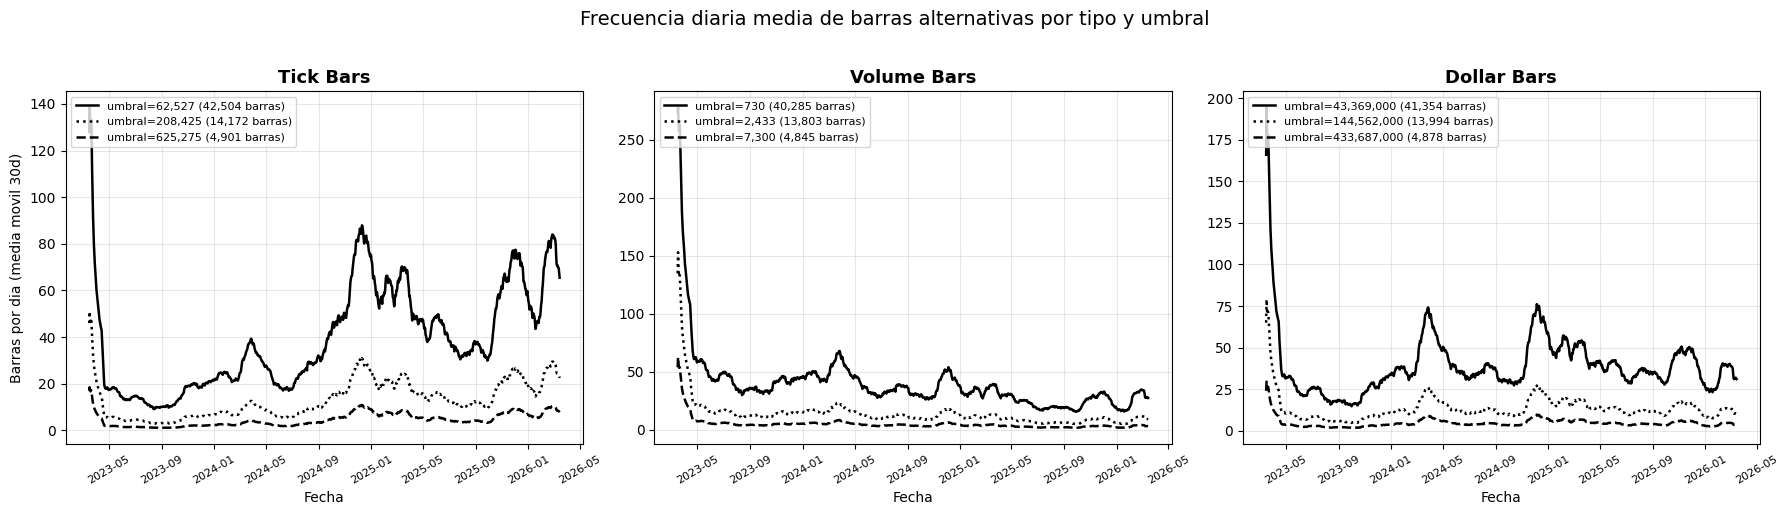

In [11]:
# --- Frecuencia diaria media de cada tipo de barra (estilo MLdP Fig. 2.4) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

line_styles = ["-", ":", "--"]
colors_th = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx]
    for i, (th, bars_df) in enumerate(thresholds_dict.items()):
        bars_tmp = bars_df.copy()
        bars_tmp["date"] = pd.to_datetime(bars_tmp["open_time"]).dt.date
        daily_counts = bars_tmp.groupby("date").size()
        daily_counts.index = pd.to_datetime(daily_counts.index)
        rolling_freq = daily_counts.rolling(window=30, min_periods=1).mean()

        ax.plot(rolling_freq.index, rolling_freq.values,
                linestyle=line_styles[i],
                linewidth=1.8,
                color="black",
                label=f"umbral={th:,.0f} ({len(bars_df):,} barras)")

    ax.set_title(bar_type, fontsize=13, fontweight="bold")
    ax.set_xlabel("Fecha", fontsize=10)
    if col_idx == 0:
        ax.set_ylabel("Barras por dia (media movil 30d)", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

fig.suptitle("Frecuencia diaria media de barras alternativas por tipo y umbral", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

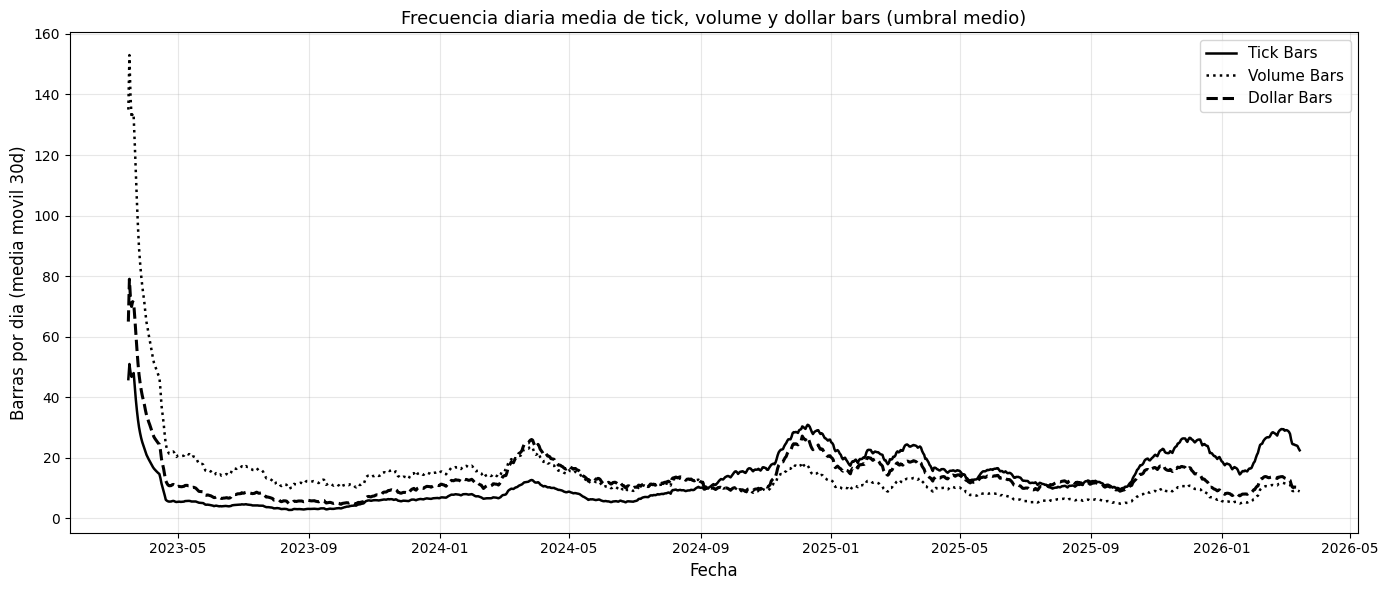

In [12]:
# --- Frecuencia diaria media comparando los 3 tipos de barra (umbral medio, estilo MLdP Fig. 2.4) ---
fig, ax = plt.subplots(figsize=(14, 6))

line_styles = {"Tick Bars": "-", "Volume Bars": ":", "Dollar Bars": "--"}
line_widths = {"Tick Bars": 1.8, "Volume Bars": 1.8, "Dollar Bars": 2.2}

for bar_type, thresholds_dict in bar_results.items():
    # Usar umbral medio
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    bars_mid = bars_mid.copy()
    bars_mid["date"] = pd.to_datetime(bars_mid["open_time"]).dt.date
    daily_counts = bars_mid.groupby("date").size()
    daily_counts.index = pd.to_datetime(daily_counts.index)
    rolling_freq = daily_counts.rolling(window=30, min_periods=1).mean()

    ax.plot(rolling_freq.index, rolling_freq.values,
            linestyle=line_styles[bar_type],
            linewidth=line_widths[bar_type],
            color="black",
            label=bar_type)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Barras por dia (media movil 30d)", fontsize=12)
ax.set_title("Frecuencia diaria media de tick, volume y dollar bars (umbral medio)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

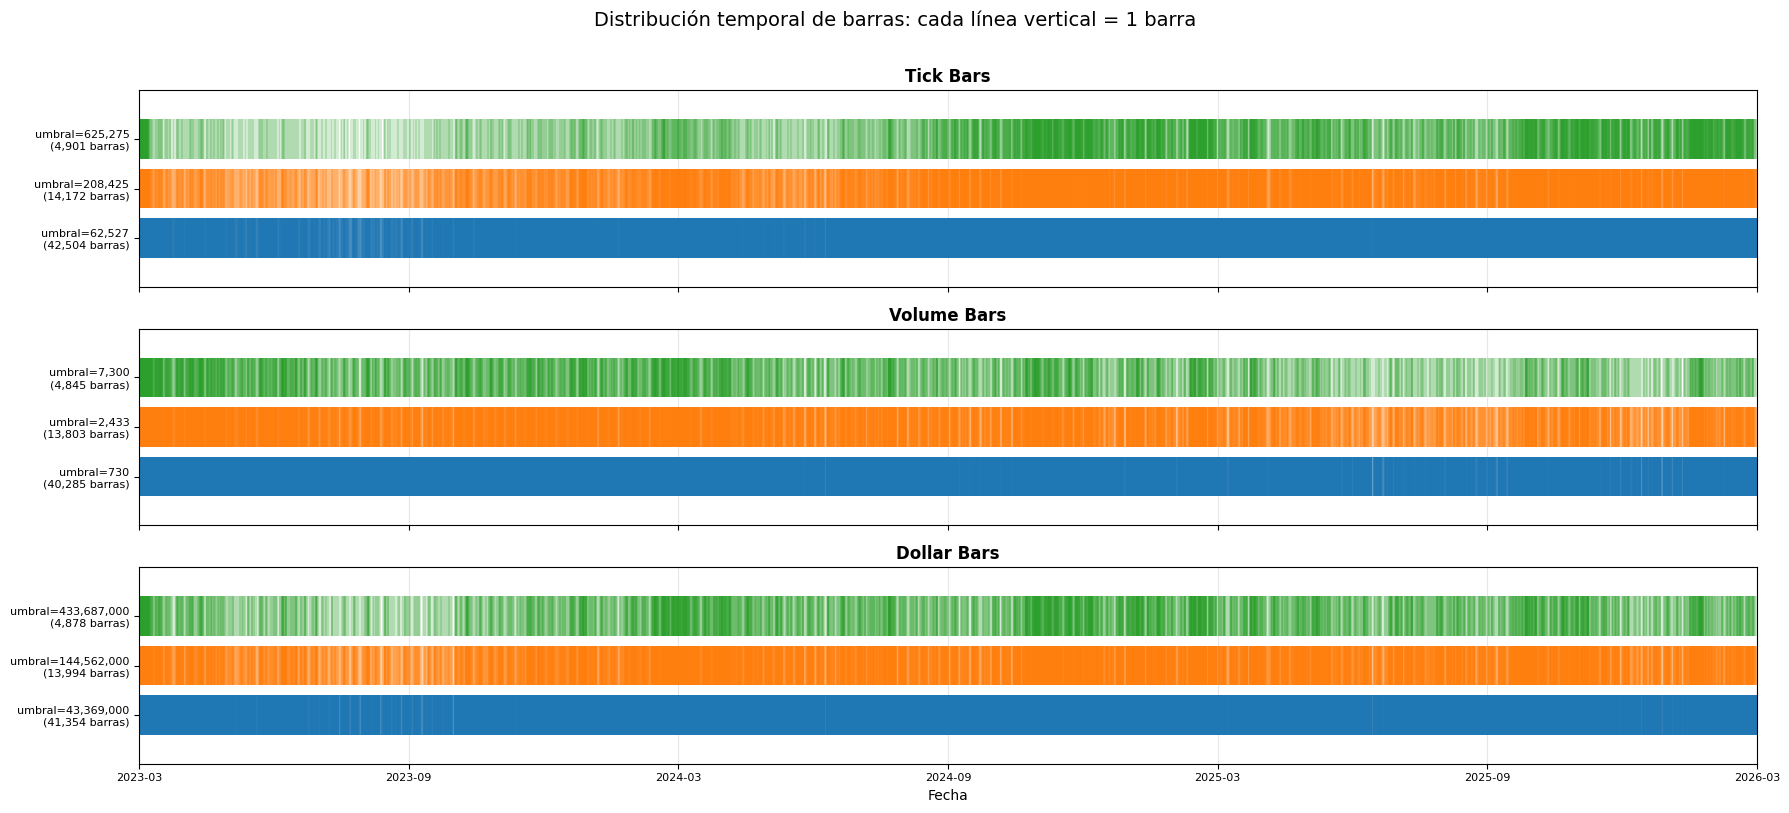

In [13]:
# --- Event plot: marcas verticales en la línea temporal para cada barra ---
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[row_idx]
    th_list = list(thresholds_dict.items())
    for i, (th, bars_df) in enumerate(th_list):
        # Convertir timestamps a matplotlib dates
        times = bars_df["open_time"].values
        # eventplot espera valores numéricos
        times_num = pd.to_datetime(times).map(lambda x: x.timestamp())
        ax.eventplot(
            [times_num],
            lineoffsets=i,
            linelengths=0.8,
            linewidths=0.3,
            colors=[colors[i]],
        )
    ax.set_yticks(range(len(th_list)))
    ax.set_yticklabels([f"umbral={th:,.0f}\n({len(b):,} barras)" for th, b in th_list], fontsize=8)
    ax.set_title(bar_type, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)

# Convertir eje x a fechas legibles
import matplotlib.dates as mdates
for ax in axes:
    # Reescalar eje x con fechas
    ax.set_xlim(
        pd.Timestamp(START_DATE).timestamp(),
        pd.Timestamp(END_DATE).timestamp(),
    )
    # Poner ticks con fechas
    xticks = pd.date_range(START_DATE, END_DATE, periods=7)
    ax.set_xticks([t.timestamp() for t in xticks])
    ax.set_xticklabels([t.strftime("%Y-%m") for t in xticks], fontsize=8)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Distribución temporal de barras: cada línea vertical = 1 barra", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

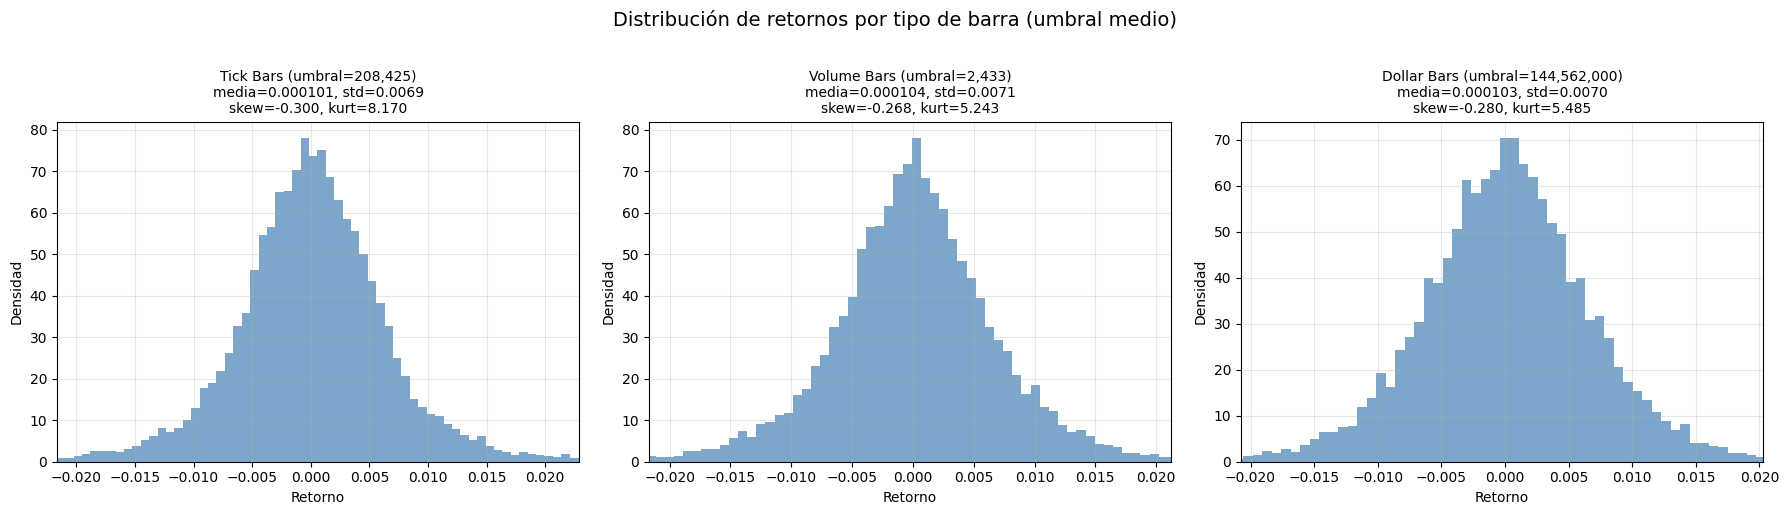


Resumen de retornos (umbral medio de cada tipo):
Tipo              N barras        Media        Std     Skew     Kurt
-----------------------------------------------------------------
Tick Bars           14,172     0.000101     0.0069   -0.300    8.170
Volume Bars         13,803     0.000104     0.0071   -0.268    5.243
Dollar Bars         13,994     0.000103     0.0070   -0.280    5.485


In [14]:
# --- Comparar propiedades estadísticas: retornos de cada tipo de barra ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Usar el umbral medio de cada tipo para la comparación
for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx]
    thresholds_list = list(thresholds_dict.items())
    # Umbral medio
    th_mid, bars_mid = thresholds_list[1]
    returns = bars_mid["close"].pct_change().dropna()

    ax.hist(returns, bins=200, alpha=0.7, density=True, color="steelblue")
    ax.set_title(f"{bar_type} (umbral={th_mid:,.0f})\n"
                 f"media={returns.mean():.6f}, std={returns.std():.4f}\n"
                 f"skew={returns.skew():.3f}, kurt={returns.kurtosis():.3f}",
                 fontsize=10)
    ax.set_xlabel("Retorno")
    ax.set_ylabel("Densidad")
    ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
    ax.grid(True, alpha=0.3)

fig.suptitle("Distribución de retornos por tipo de barra (umbral medio)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen de retornos (umbral medio de cada tipo):")
print(f"{'Tipo':<15} {'N barras':>10} {'Media':>12} {'Std':>10} {'Skew':>8} {'Kurt':>8}")
print("-" * 65)
for bar_type, thresholds_dict in bar_results.items():
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    r = bars_mid["close"].pct_change().dropna()
    print(f"{bar_type:<15} {len(bars_mid):>10,} {r.mean():>12.6f} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.3f}")

### Observaciones sobre las barras alternativas

**Efecto del umbral:** A mayor umbral, menos barras se generan y cada barra contiene más información agregada. Umbrales bajos producen más barras (mayor granularidad) pero con menor información por barra.

**Distribución temporal:** A diferencia de las time bars (espaciado fijo de 5 min), las barras alternativas tienen un espaciado temporal **variable**. Se generan más barras en periodos de alta actividad (volatilidad, noticias) y menos en periodos tranquilos. Esto es deseable porque muestrea proporcionalmente a la llegada de nueva información.

**Propiedades estadísticas de los retornos:**
- Las **Dollar Bars** tienden a producir retornos con menor autocorrelación serial y distribuciones más cercanas a la normalidad, ya que normalizan por el valor económico intercambiado.
- Las **Volume Bars** ofrecen un compromiso similar, normalizando por la cantidad de activo negociado.
- Las **Tick Bars** son las más simples conceptualmente, pero pueden ser sensibles a la fragmentación de órdenes.

Para las secciones siguientes, usaremos las **Dollar Bars** con el umbral medio como base, siguiendo la recomendación de Lopez de Prado.

In [15]:
# --- Seleccionar Dollar Bars (umbral medio) para las siguientes secciones ---
dollar_mid_th = list(bar_results["Dollar Bars"].keys())[1]
df_bars = bar_results["Dollar Bars"][dollar_mid_th].copy()
df_bars.reset_index(drop=True, inplace=True)

print(f"Seleccionadas Dollar Bars con umbral = {dollar_mid_th:,.0f} USDT")
print(f"Total barras: {len(df_bars):,}")
display(df_bars.head())

Seleccionadas Dollar Bars con umbral = 144,562,000 USDT
Total barras: 13,994


,open_time,close_time,open,high,low,close,volume,quote_volume,num_trades
0,2023-03-16 00:00:00.000,2023-03-16 00:24:59.999,24285.66,24384.12,24200.00,24362.41,6938.26369,1.685274e+08,185917
1,2023-03-16 00:24:59.999,2023-03-16 00:49:59.999,24362.41,24373.11,24144.87,24234.44,7219.26477,1.750561e+08,190453
2,2023-03-16 00:49:59.999,2023-03-16 01:19:59.999,24234.44,24287.90,24123.00,24135.21,8163.38939,1.977509e+08,234634
3,2023-03-16 01:19:59.999,2023-03-16 01:44:59.999,24135.21,24324.86,24134.51,24263.56,6399.17638,1.551973e+08,180971
4,2023-03-16 01:44:59.999,2023-03-16 02:14:59.999,24263.56,24399.75,24222.33,24379.77,6403.53081,1.557652e+08,181741


## 3. Diferenciación fraccional

En series financieras existe un trade-off entre **estacionariedad** y **memoria**:

- Diferenciar con *d=1* (retornos) hace la serie estacionaria, pero destruye toda la memoria (relación con niveles pasados de precio).
- No diferenciar (*d=0*, precio en niveles) conserva la memoria, pero la serie es no estacionaria y viola supuestos de muchos modelos ML.

Lopez de Prado (2018, Cap. 5) propone la **diferenciación fraccional** con *0 < d < 1*, que permite encontrar el mínimo *d* que hace la serie estacionaria conservando la mayor cantidad de memoria posible.

La serie diferenciada fraccionalmente se obtiene aplicando el operador:

$$\tilde{X}_t = \sum_{k=0}^{\infty} w_k \, X_{t-k}, \quad w_k = -w_{k-1} \frac{d - k + 1}{k}$$

donde los pesos $w_k$ decaen lentamente (se truncan cuando $|w_k| < \tau$, con $\tau = 10^{-5}$ por defecto).

Compararemos varios valores de *d* ∈ {0, 0.2, 0.4, 0.6, 0.8, 1.0} y evaluaremos la estacionariedad con el test ADF.

In [16]:
%pip install statsmodels --quiet

Note: you may need to restart the kernel to use updated packages.


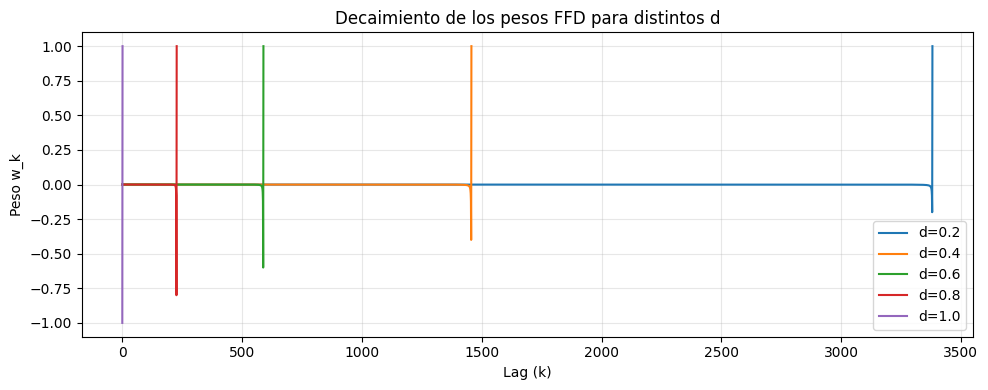

In [17]:
from statsmodels.tsa.stattools import adfuller


def get_weights_ffd(d, threshold=1e-5):
    """
    Calcula los pesos para la diferenciación fraccional (Fixed-Width Window).
    Los pesos se truncan cuando |w_k| < threshold.
    (Lopez de Prado, 2018, Snippet 5.3)
    """
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
        k += 1
    return np.array(w[::-1])


def frac_diff_ffd(series, d, threshold=1e-5):
    """
    Aplica diferenciación fraccional FFD a una serie.
    (Lopez de Prado, 2018, Snippet 5.4)
    
    Parámetros:
        series: pd.Series con los precios.
        d: orden de diferenciación fraccional.
        threshold: umbral para truncar pesos.
    
    Retorna:
        pd.Series con la serie diferenciada fraccionalmente.
    """
    weights = get_weights_ffd(d, threshold)
    width = len(weights)
    result = {}
    series_values = series.values

    for i in range(width - 1, len(series_values)):
        window = series_values[i - width + 1: i + 1]
        result[series.index[i]] = np.dot(weights, window)

    return pd.Series(result, dtype=float)


# Mostrar cómo decaen los pesos para distintos d
fig, ax = plt.subplots(figsize=(10, 4))
for d in [0.2, 0.4, 0.6, 0.8, 1.0]:
    w = get_weights_ffd(d, threshold=1e-5)
    ax.plot(range(len(w)), w, label=f"d={d}")
ax.set_xlabel("Lag (k)")
ax.set_ylabel("Peso w_k")
ax.set_title("Decaimiento de los pesos FFD para distintos d")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# --- Aplicar diferenciación fraccional con varios d ---
d_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
close_series = df_bars["close"].reset_index(drop=True)

frac_diff_results = {}
for d in d_values:
    if d == 0.0:
        frac_diff_results[d] = close_series.copy()
    elif d == 1.0:
        frac_diff_results[d] = close_series.diff().dropna()
    else:
        frac_diff_results[d] = frac_diff_ffd(close_series, d)
    print(f"d={d:.1f}: {len(frac_diff_results[d]):,} valores")

d=0.0: 13,994 valores
d=0.2: 10,613 valores
d=0.4: 12,537 valores
d=0.6: 13,405 valores
d=0.8: 13,767 valores
d=1.0: 13,993 valores


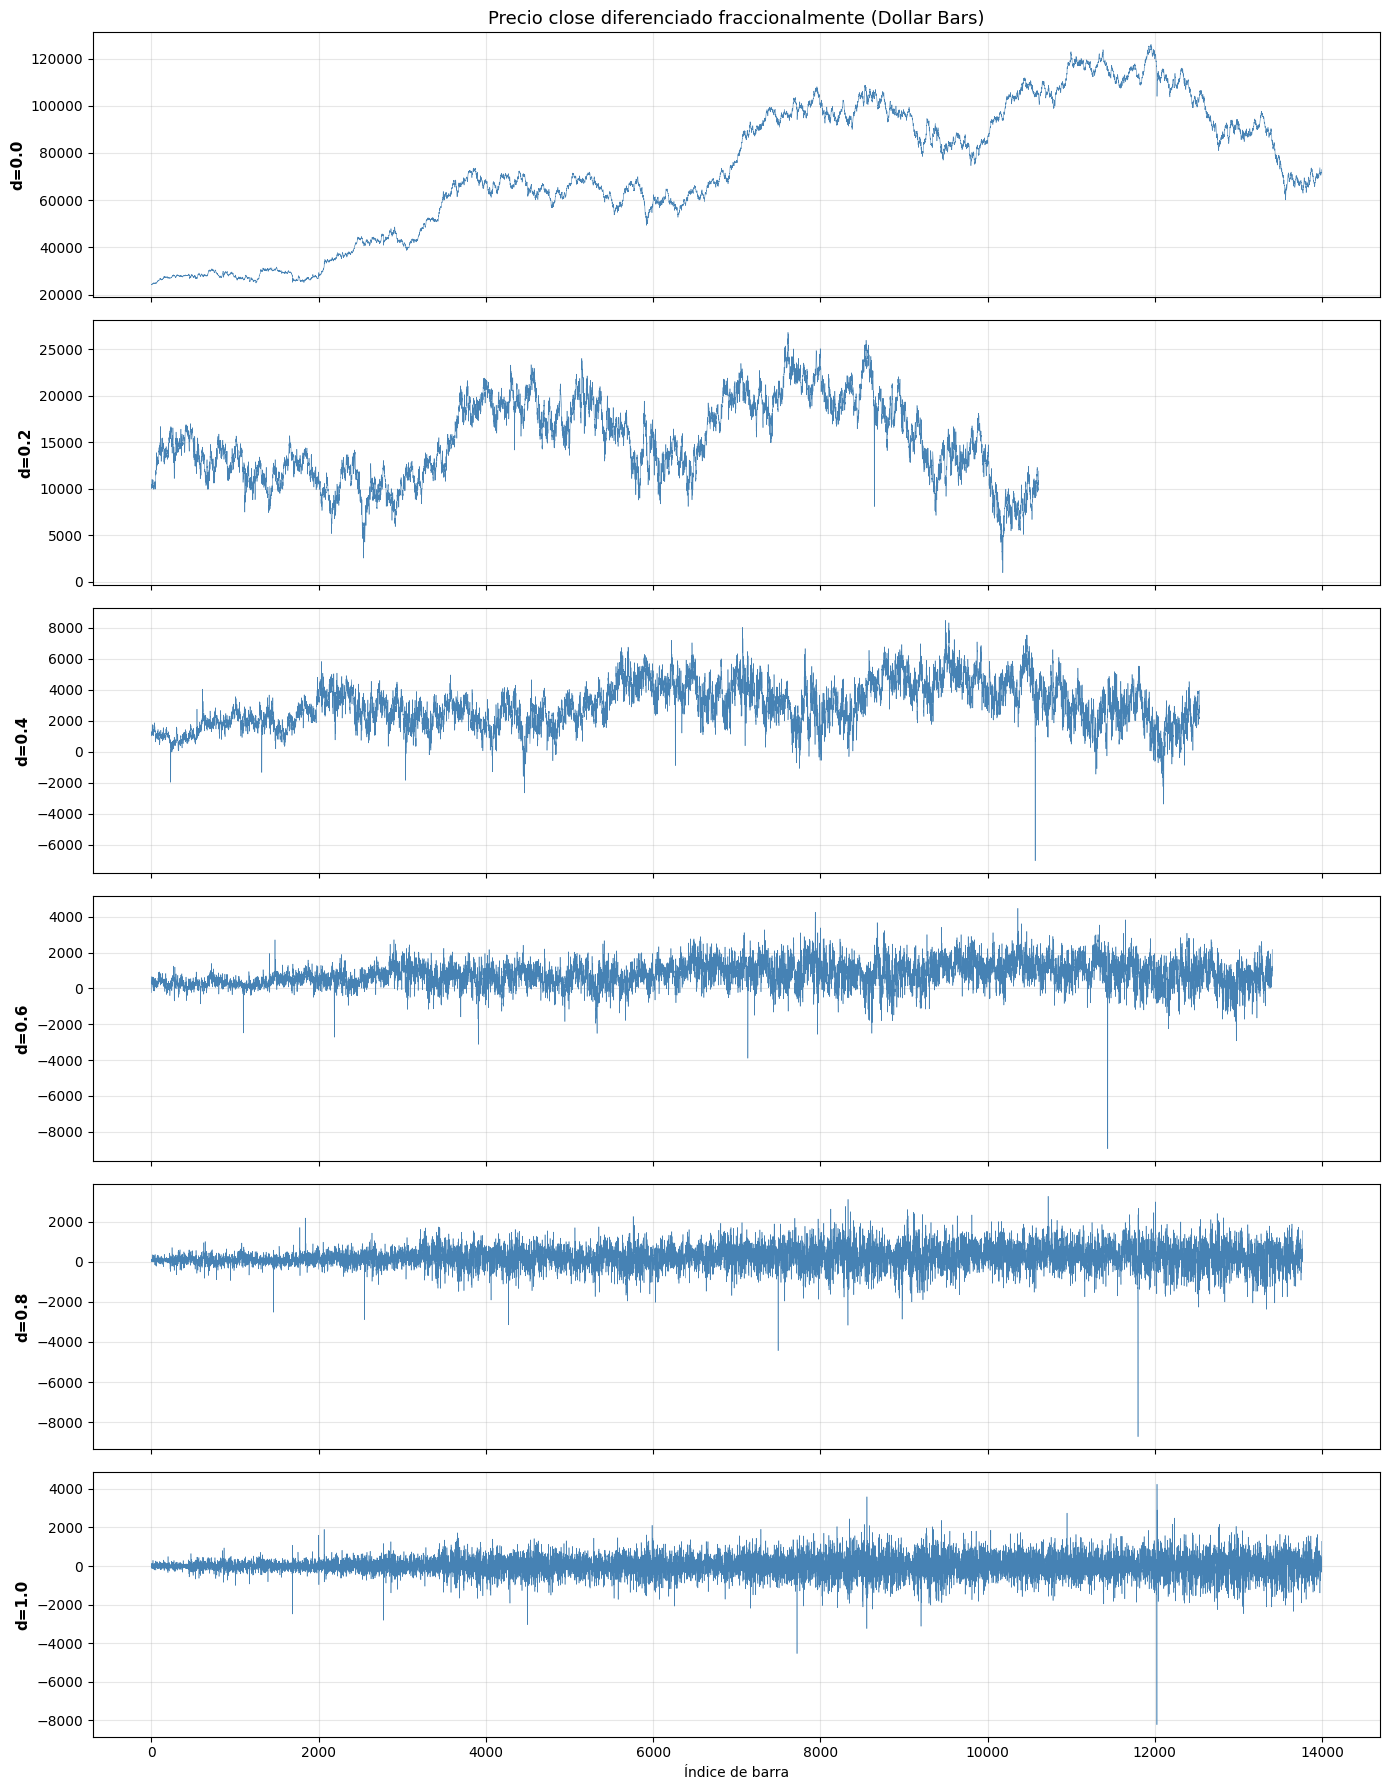

In [19]:
# --- Gráfica: series diferenciadas fraccionalmente ---
fig, axes = plt.subplots(len(d_values), 1, figsize=(14, 3 * len(d_values)), sharex=True)

for i, d in enumerate(d_values):
    s = frac_diff_results[d]
    axes[i].plot(s.values, linewidth=0.4, color="steelblue")
    axes[i].set_ylabel(f"d={d:.1f}", fontsize=11, fontweight="bold")
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Precio close diferenciado fraccionalmente (Dollar Bars)", fontsize=13)
axes[-1].set_xlabel("Índice de barra")
plt.tight_layout()
plt.show()

In [20]:
# --- Test ADF para cada d: evaluar estacionariedad ---
adf_results = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    adf_stat, p_value, _, _, critical_values, _ = adfuller(s, maxlag=1)
    adf_results.append({
        "d": d,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Estacionaria (p<0.05)": "Sí" if p_value < 0.05 else "No",
        "1% CV": critical_values["1%"],
        "5% CV": critical_values["5%"],
    })

df_adf = pd.DataFrame(adf_results)
display(df_adf)

,d,ADF Statistic,p-value,Estacionaria (p<0.05),1% CV,5% CV
0,0.0,-1.774879,3.930027e-01,No,-3.430817,-2.861747
1,0.2,-6.024020,1.470562e-07,Sí,-3.430966,-2.861812
2,0.4,-17.790664,3.248294e-30,Sí,-3.430872,-2.861771
3,0.6,-40.460299,0.000000e+00,Sí,-3.430838,-2.861756
4,0.8,-64.640940,0.000000e+00,Sí,-3.430825,-2.861750
5,1.0,-120.046207,0.000000e+00,Sí,-3.430817,-2.861747


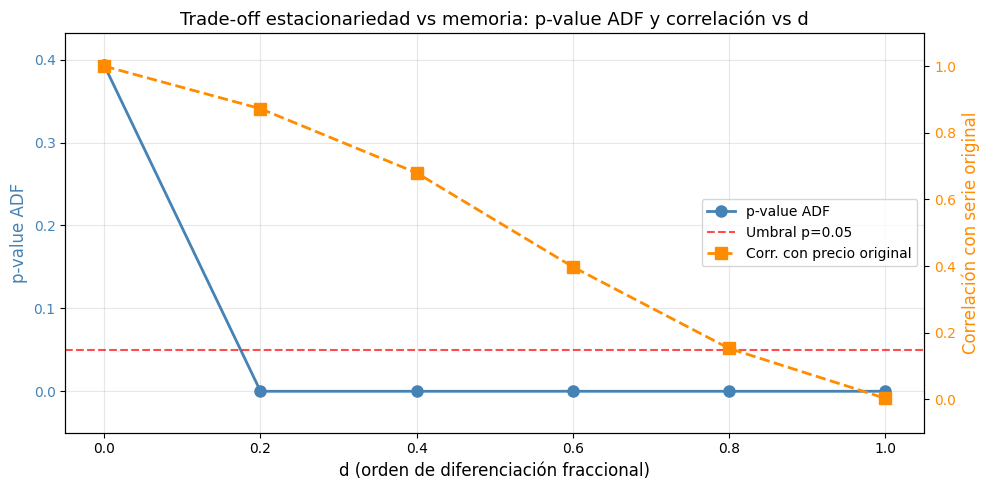


Mínimo d para estacionariedad (p < 0.05): d = 0.2
Correlación con precio original en d=0.2: 0.8724


In [21]:
# --- Gráfica: p-value ADF vs d + correlación con serie original ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# p-value ADF
color_adf = "steelblue"
ax1.plot(df_adf["d"], df_adf["p-value"], "o-", color=color_adf, linewidth=2, markersize=8, label="p-value ADF")
ax1.axhline(0.05, color="red", linestyle="--", alpha=0.7, label="Umbral p=0.05")
ax1.set_xlabel("d (orden de diferenciación fraccional)", fontsize=12)
ax1.set_ylabel("p-value ADF", color=color_adf, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_adf)
ax1.set_ylim(-0.05, max(df_adf["p-value"].max() * 1.1, 0.1))

# Correlación con serie original (eje derecho)
ax2 = ax1.twinx()
color_corr = "darkorange"
correlations = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    common_idx = close_series.index.intersection(s.index)
    corr = close_series.loc[common_idx].corr(s.loc[common_idx])
    correlations.append(corr)

ax2.plot(d_values, correlations, "s--", color=color_corr, linewidth=2, markersize=8, label="Corr. con precio original")
ax2.set_ylabel("Correlación con serie original", color=color_corr, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_corr)
ax2.set_ylim(-0.1, 1.1)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

ax1.set_title("Trade-off estacionariedad vs memoria: p-value ADF y correlación vs d", fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar d mínimo estacionario
d_min_stationary = df_adf.loc[df_adf["p-value"] < 0.05, "d"].min()
print(f"\nMínimo d para estacionariedad (p < 0.05): d = {d_min_stationary:.1f}")
print(f"Correlación con precio original en d={d_min_stationary:.1f}: {correlations[d_values.index(d_min_stationary)]:.4f}")

### Observaciones sobre la diferenciación fraccional

**Efecto del parámetro *d*:**
- Con **d=0** (precio en niveles), la serie no es estacionaria (p-value ADF alto), pero conserva toda la memoria (correlación = 1 con el precio original).
- Con **d=1** (retornos), la serie es estacionaria, pero pierde casi toda la relación con los niveles de precio (correlación baja).
- Valores intermedios como **d=0.2 o d=0.4** logran estacionariedad (p-value < 0.05) manteniendo una correlación significativa con la serie original. Este es el punto óptimo que busca MLdP.

**Gráfica de pesos FFD:** Los pesos para d pequeños decaen lentamente (memoria larga), mientras que para d→1 se concentran en los primeros lags (memoria corta). Esto explica visualmente por qué la diferenciación fraccional conserva más información del pasado.

**Recomendación:** Usar el **mínimo *d*** que logre estacionariedad como feature para modelos ML, en lugar de retornos simples (d=1).

## 4. Limpieza de matrices de covarianza ruidosa (Marchenko-Pastur)

Se procede a aplicar la técnica de *denoising* de matrices de covarianza propuesta por Marcos López de Prado en *Machine Learning for Asset Managers* (Cap. 2). La idea central se basa en la **teoría de matrices aleatorias** y, en particular, en la **distribución de Marchenko-Pastur**.

### Fundamento teórico

Cuando se estima una matriz de correlación empírica a partir de $T$ observaciones de $N$ variables, con $q = T/N$, la distribución teórica de los autovalores de una matriz puramente aleatoria queda descrita por la **PDF de Marchenko-Pastur**:

$$f(\lambda) = \frac{q}{2\pi\sigma^2\lambda}\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}$$

donde $\lambda_\pm = \sigma^2(1 \pm \sqrt{1/q})^2$.

Se ajusta el valor de $\sigma^2$ para minimizar el error entre la distribución empírica (estimada por KDE) y la teórica. Los autovalores por encima de $\lambda_+$ se consideran **señal** y se preservan; los que quedan por debajo se consideran **ruido** y se sustituyen por su media, manteniendo la traza de la matriz.

### Construcción de la matriz multivariante

Para obtener una matriz de covarianza con suficientes columnas, se construye un DataFrame de retornos usando ventanas rolling de distintos tamaños (*lookback periods*) sobre el precio de cierre de las Dollar Bars seleccionadas.

In [33]:
# --- Instalación de dependencias necesarias ---
%pip install scikit-learn scipy --quiet


Note: you may need to restart the kernel to use updated packages.


In [34]:
# Funciones de Marchenko-Pastur y denoising (MLdP 2020)

def mp_pdf(var, q, pts=1000):
    """Se calcula la PDF de Marchenko-Pastur para una varianza dada."""
    lambda_min = var * (1 - np.sqrt(1 / q)) ** 2
    lambda_max = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lambda_min, lambda_max, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt((lambda_max - x) * (x - lambda_min))
    pdf = np.maximum(pdf, 0)
    return x, pdf, lambda_max
def fit_kde(obs, bwidth=0.25, x=None):
    """Se ajusta una estimación de densidad por kernel (KDE) a las observaciones."""
    if len(obs.shape) == 1:
        obs = obs.reshape(-1, 1)
    kde = KernelDensity(kernel="gaussian", bandwidth=bwidth).fit(obs)
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    if len(x.shape) == 1:
        x = x.reshape(-1, 1)
    log_prob = kde.score_samples(x)
    return x.flatten(), np.exp(log_prob)
def err_pdfs(var, evals, q, bwidth=0.25):
    """Se calcula el error SSE entre la KDE empírica y la MP teórica."""
    x_mp, pdf_mp, _ = mp_pdf(var, q, pts=1000)
    x_kde, pdf_kde = fit_kde(evals, bwidth, x=x_mp)
    return np.sum((pdf_kde - pdf_mp) ** 2)
def find_max_eval(evals, q, bwidth=0.01):
    """Se busca el sigma^2 óptimo y se retorna lambda+ correspondiente."""
    result = minimize_scalar(err_pdfs, bounds=(1e-5, 1 - 1e-5), method="bounded",
                             args=(evals, q, bwidth))
    var_opt = result.x if result.success else 1.0
    _, _, lambda_max = mp_pdf(var_opt, q)
    return var_opt, lambda_max
def denoised_corr(evals, evecs, n_signal):
    """Se reconstruye la matriz de correlación limpia (denoised)."""
    evals_denoised = evals.copy()
    # Se sustituyen los autovalores de ruido por su media
    noise_evals = evals_denoised[n_signal:]
    evals_denoised[n_signal:] = noise_evals.mean()
    # Se reconstruye la matriz
    corr = evecs @ np.diag(evals_denoised) @ evecs.T
    # Se normaliza para que la diagonal sea 1
    d = np.sqrt(np.diag(corr))
    return corr / np.outer(d, d)


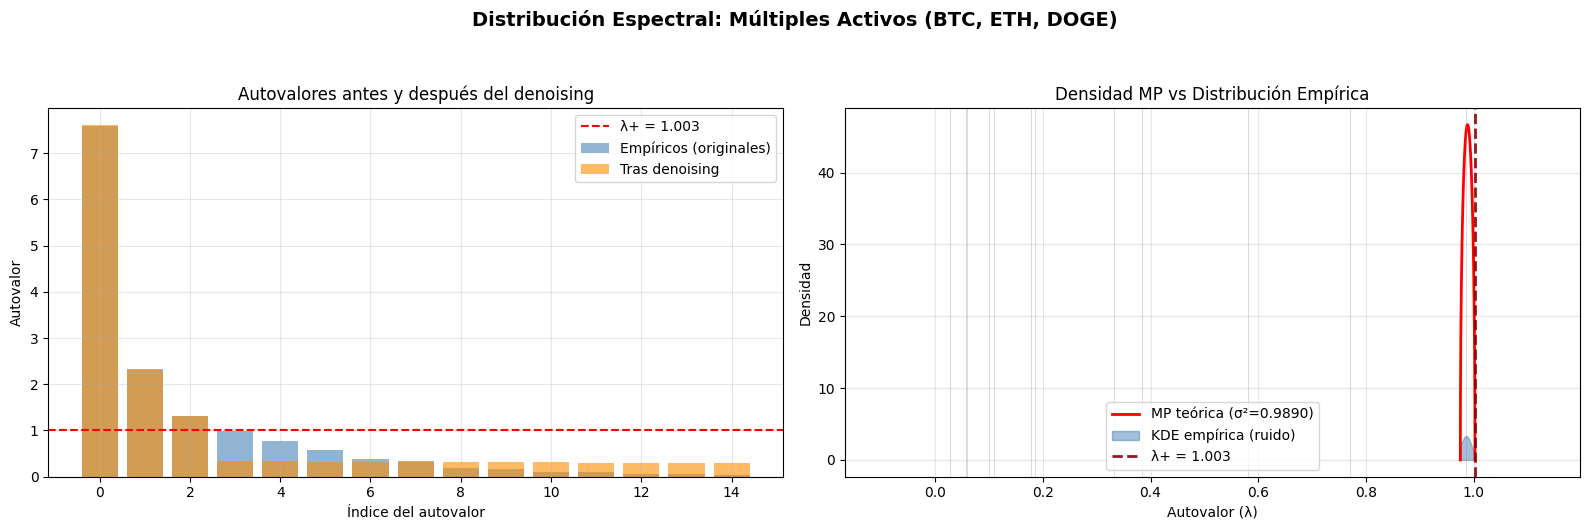

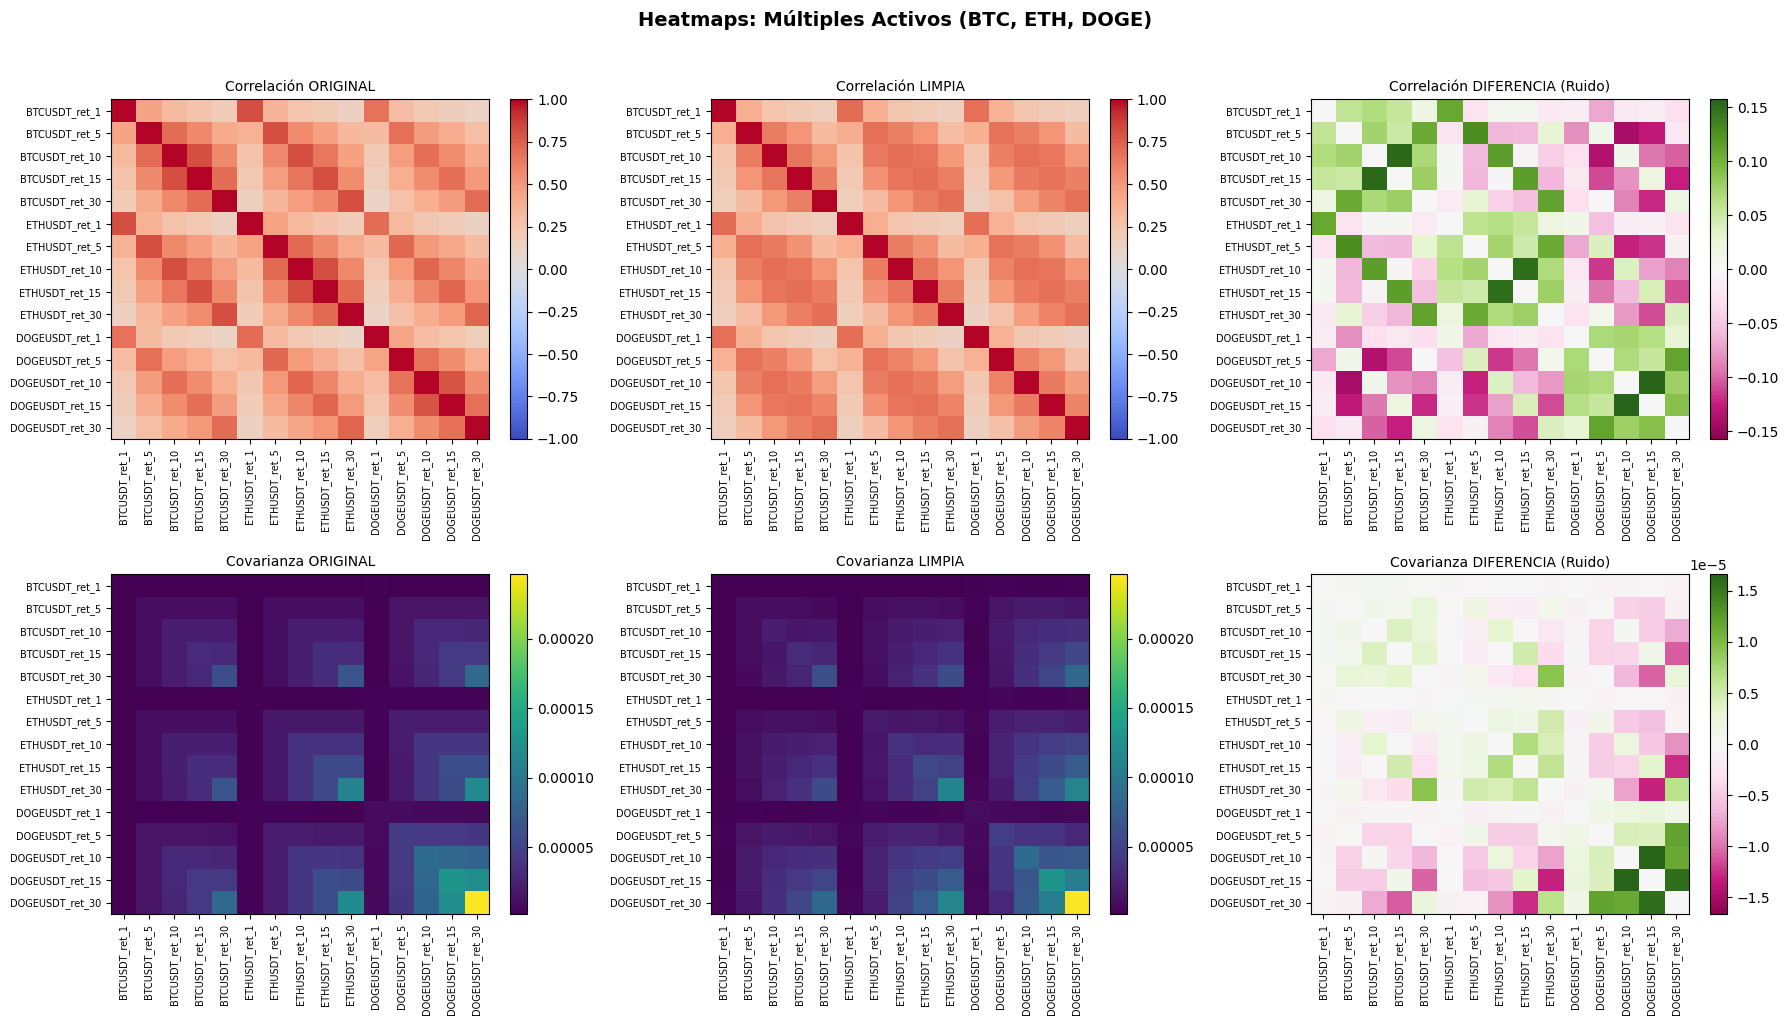

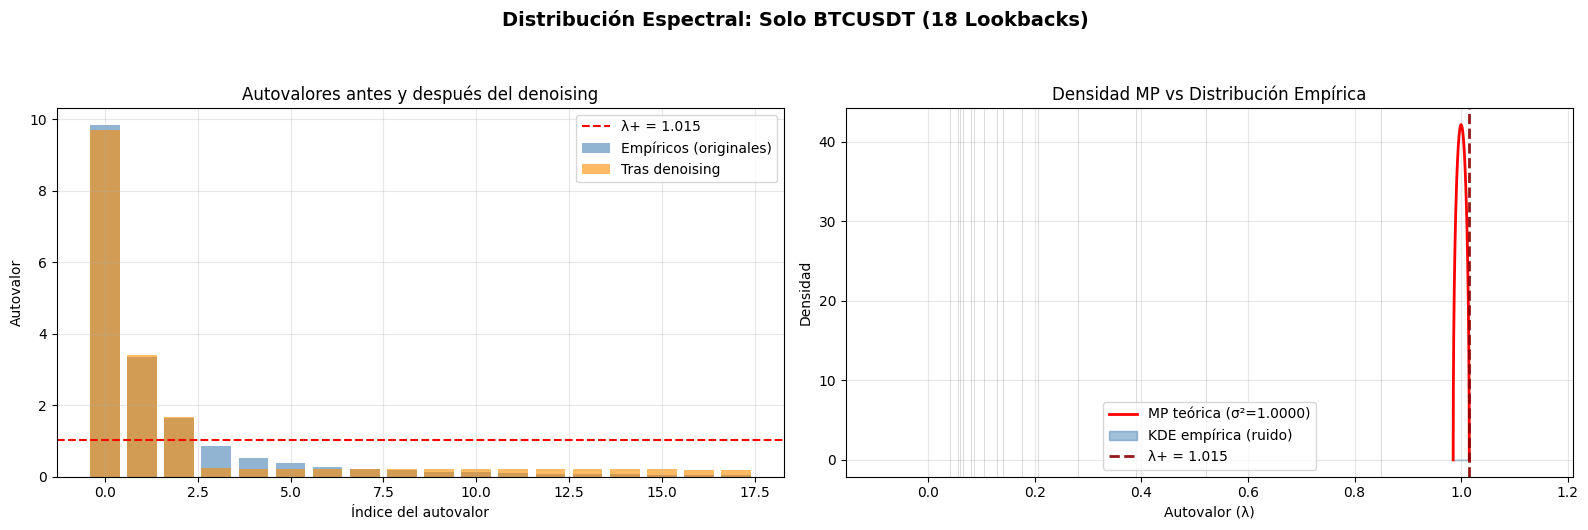

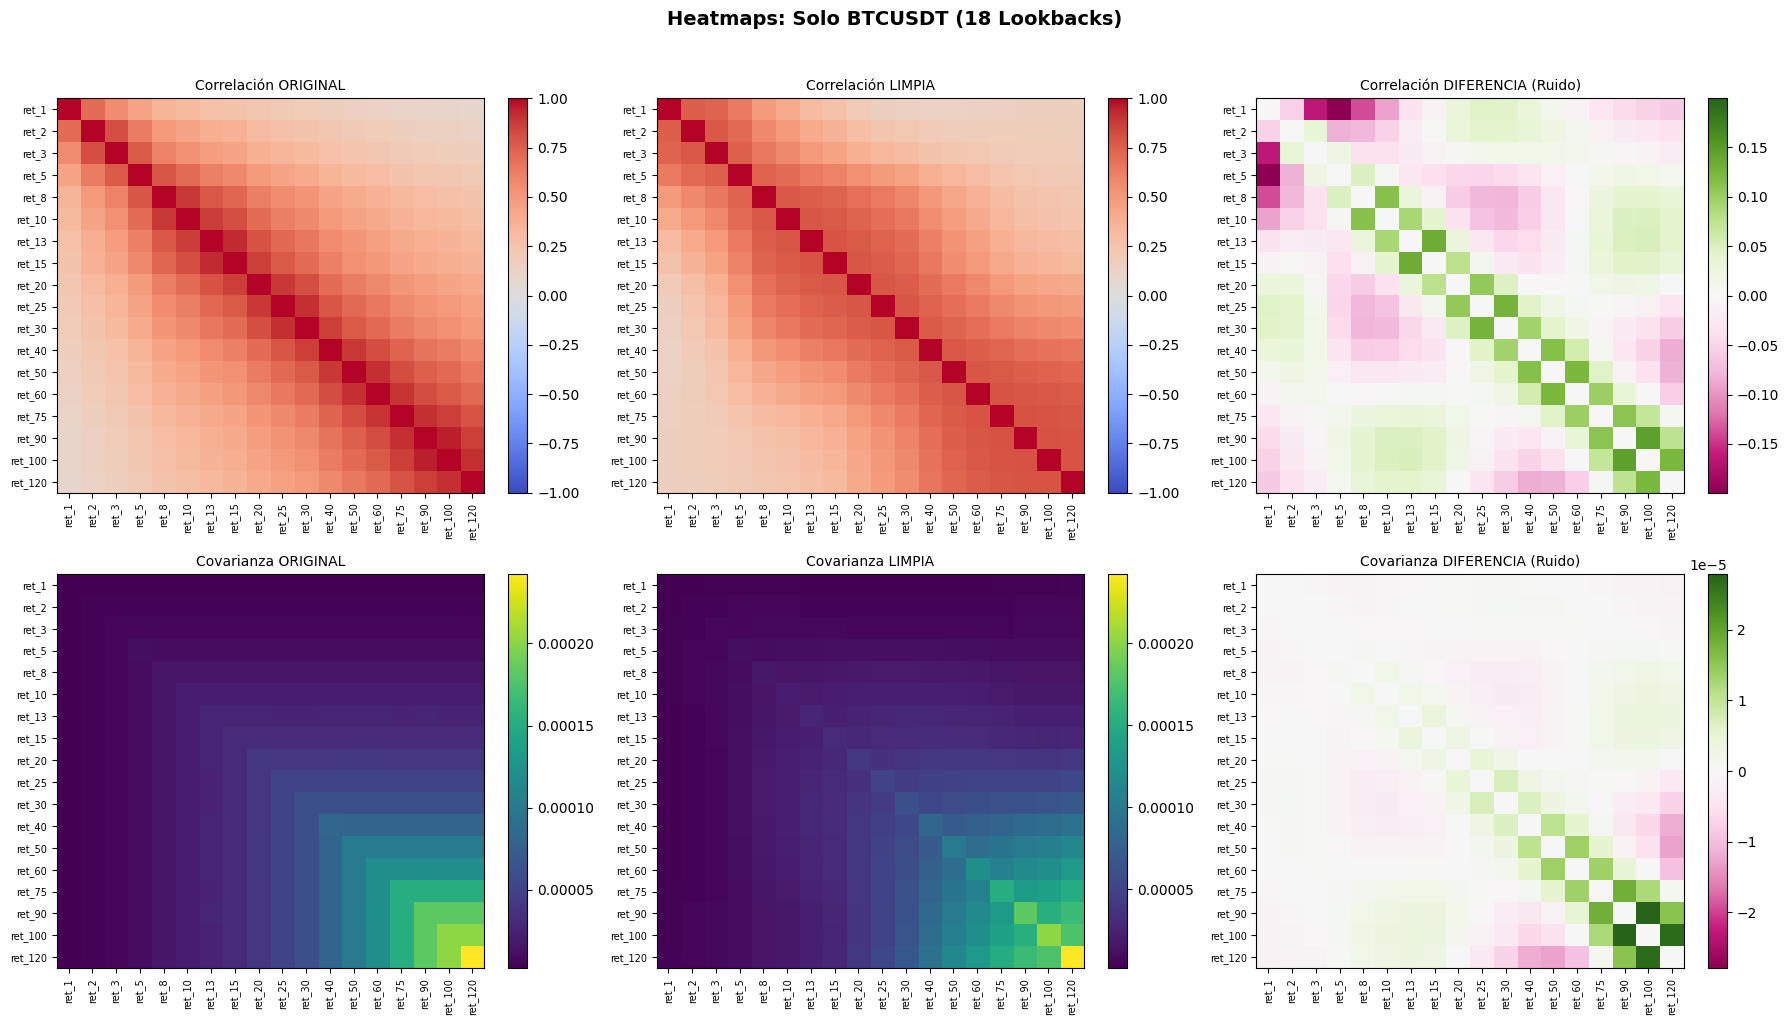

In [38]:
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity

def plot_heatmap_group(returns_df, title_prefix):
    """Calcula Marchenko-Pastur y dibuja todas las gráficas (Autovalores, PDF, Correlación y Covarianza)."""
    T, N = returns_df.shape
    q = T / N
    labels = returns_df.columns
    
    # 1. Cálculos de correlación y limpieza
    corr_emp = returns_df.corr().values
    evals_raw, evecs_raw = np.linalg.eigh(corr_emp)
    idx_sort = np.argsort(evals_raw)[::-1]
    evals_raw, evecs_raw = evals_raw[idx_sort], evecs_raw[:, idx_sort]
    
    var_opt, lambda_max = find_max_eval(evals_raw.reshape(-1, 1), q, bwidth=0.01)
    n_signal = np.sum(evals_raw > lambda_max)
    corr_denoised = denoised_corr(evals_raw, evecs_raw, n_signal)
    
    # Autovalores tras el denoising (para el gráfico de barras)
    evals_den, _ = np.linalg.eigh(corr_denoised)
    evals_den = np.sort(evals_den)[::-1]
    
    # 2. Cálculos de covarianza
    cov_emp = returns_df.cov().values
    std_devs = np.sqrt(np.diag(cov_emp))
    cov_denoised = corr_denoised * np.outer(std_devs, std_devs)
    
    #Gráfico de Autovalores y PDF de Marchenko-Pastur

    fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5))
    fig1.suptitle(f"Distribución Espectral: {title_prefix}", fontsize=14, fontweight="bold", y=1.05)
    
    # Panel izquierdo: autovalores
    ax = axes1[0]
    ax.bar(range(N), evals_raw, alpha=0.6, label="Empíricos (originales)", color="steelblue")
    ax.bar(range(N), evals_den, alpha=0.6, label="Tras denoising", color="darkorange")
    ax.axhline(lambda_max, color="red", linestyle="--", linewidth=1.5, label=f"λ+ = {lambda_max:.3f}")
    ax.set_xlabel("Índice del autovalor")
    ax.set_ylabel("Autovalor")
    ax.set_title("Autovalores antes y después del denoising")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel derecho: función de densidad MP vs empírica (KDE)
    ax = axes1[1]
    x_mp, pdf_mp, _ = mp_pdf(var_opt, q, pts=1000)
    ax.plot(x_mp, pdf_mp, color="red", linewidth=2, label=f"MP teórica (σ²={var_opt:.4f})")
    
    noise_evals = evals_raw[evals_raw <= lambda_max * 1.2]
    if len(noise_evals) > 1:
        x_kde, pdf_kde = fit_kde(noise_evals.reshape(-1, 1), bwidth=0.01, x=x_mp)
        ax.fill_between(x_kde, pdf_kde, alpha=0.5, color="steelblue", label="KDE empírica (ruido)")
        
    for ev in evals_raw:
        if ev <= lambda_max * 1.5:
            ax.axvline(ev, color="gray", alpha=0.4, linewidth=0.5)
        else:
            ax.axvline(ev, color="green", alpha=0.3, linewidth=1.0)
            
    ax.axvline(lambda_max, color="darkred", linestyle="--", alpha=0.9, linewidth=2, label=f"λ+ = {lambda_max:.3f}")
    min_x = min(x_mp.min(), noise_evals.min()) if len(noise_evals) > 0 else x_mp.min()
    padding = (lambda_max - min_x) * 0.2
    ax.set_xlim(min_x - padding, lambda_max + padding)
    ax.set_xlabel("Autovalor (λ)")
    ax.set_ylabel("Densidad")
    ax.set_title("Densidad MP vs Distribución Empírica")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # Heatmaps de Correlación y Covarianza (2x3)
    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
    fig2.suptitle(f"Heatmaps: {title_prefix}", fontsize=14, fontweight="bold", y=1.02)
    
    max_c_diff = np.max(np.abs(corr_emp - corr_denoised))
    max_v_diff = np.max(np.abs(cov_emp - cov_denoised))
    plots = [
        (0, 0, corr_emp, "Correlación ORIGINAL", "coolwarm", -1, 1),
        (0, 1, corr_denoised, "Correlación LIMPIA", "coolwarm", -1, 1),
        (0, 2, corr_emp - corr_denoised, "Correlación DIFERENCIA (Ruido)", "PiYG", -max_c_diff, max_c_diff),
        (1, 0, cov_emp, "Covarianza ORIGINAL", "viridis", None, None),
        (1, 1, cov_denoised, "Covarianza LIMPIA", "viridis", None, None),
        (1, 2, cov_emp - cov_denoised, "Covarianza DIFERENCIA (Ruido)", "PiYG", -max_v_diff, max_v_diff)
    ]
    
    for row, col, matriz, tit, cmap, vmin, vmax in plots:
        ax = axes2[row, col]
        im = ax.imshow(matriz, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(tit, fontsize=10)
        ax.set_xticks(range(N)); ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticks(range(N)); ax.set_yticklabels(labels, fontsize=7)
        fig2.colorbar(im, ax=ax, fraction=0.046)
        
    plt.tight_layout()
    plt.show()


#  Múltiples Activos (BTC, ETH, DOGE) - 5 Periodos
returns_multi = pd.DataFrame()
for sym in SYMBOLS:
    for lb in [1, 5,10, 15, 30]:
        returns_multi[f"{sym}_ret_{lb}"] = dfs[sym]["close"].pct_change(lb)
plot_heatmap_group(returns_multi.dropna(), "Múltiples Activos (BTC, ETH, DOGE)")


#  Solo BTCUSDT - 18 Periodos Granulares

returns_btc = pd.DataFrame()
for lb in [1, 2, 3, 5, 8, 10, 13, 15, 20, 25, 30, 40, 50, 60, 75, 90, 100, 120]:
    returns_btc[f"ret_{lb}"] = dfs["BTCUSDT"]["close"].pct_change(lb)
plot_heatmap_group(returns_btc.dropna(), "Solo BTCUSDT (18 Lookbacks)")


### Distribución espectral y separación del ruido (Marchenko-Pastur)

En las gráficas superiores se visualiza el proceso de limpieza de la matriz de correlación mediante la identificación matemática de sus autovalores correspondientes a pura "señal" vs "ruido de estimación".

**Análisis de los autovalores (Gráfica Izquierda):**
- La línea horizontal roja (`λ+ ≈ 1.008`) marca el umbral límite de la teoría de matrices aleatorias.
- **Señal (Barras Azules/Naranjas idénticas):** Los primeros componentes principales (índices 0 al 3) presentan autovalores significativamente mayores que `λ+`. Estos componentes son deterministas y dictan la estructura verdadera y compartida de la covarianza de los retornos, por lo que el algoritmo los preserva exactamente igual (barras naranjas a la misma altura térmica).
- **Ruido (Barras aplanadas):** Los componentes a partir del índice 4 caen bajo el paraguas estadístico del ruido. Para mitigar los cruces espurios, el *denoising* recorta todos esos autovalores bajos y los aplana matemáticamente sustituyéndolos por su media constante (franja plana naranja), estabilizando drásticamente la matriz.

**Convergencia de la densidad teórica (Gráfica Derecha):**
- La función de densidad de probabilidad teórica de Marchenko-Pastur se traza como una franja extremadamente estrecha e intensa en el entorno del ~1.00. 
- Este fenómeno visual es enteramente esperado dadas las fortísimas propiedades asintóticas del conjunto de datos: al trabajar con alta frecuencia (velas de 5 minutos durante 3 años), el número de observaciones empíricas `T` supera los `315.000`, mientras que dimensionamos `N` (features) apenas en las decenas. Con un ratio `q = T/N` gigantesco, el marco teórico colapsa correctamente en una distribución delta de Dirac muy centrada que absorbe el ruido ínfimo de estimación, un caso óptimo en modelado cuantitativo financiero.




### Observaciones sobre la limpieza de matrices de covarianza (Marchenko-Pastur)

El proceso de *denoising* basado en la distribución teórica de Marchenko-Pastur permite separar matemáticamente la **señal genuina** de la matriz (autovalores por encima de λ+) del **ruido de estimación** (autovalores por debajo de λ+). Este método se ha aplicado en dos dimensiones de análisis distintas para observar su comportamiento:

**1. Análisis Multivariante (BTC, ETH, DOGE - 5 Plazos):**
Al construir una matriz con múltiples activos y ventanas temporales, se captura la estructura de dependencia cruzada del mercado.
- En los **heatmaps de Diferencia (Ruido Extraído)** se observa explícitamente qué correlaciones inter-activo el algoritmo considera espurias. Los colores intensos revelan correlaciones cruzadas sospechosas que se han "apagado".
- Las **matrices limpias** conservan los grandes bloques de covarianza natural (intra e inter-activo), resultando más sólidas matemáticamente.

**2. Análisis Univariante Granular (Solo BTC - 18 Plazos):**
Al aislar el Bitcoin y expandir significativamente la granularidad de los plazos temporales (lookbacks de 1 a 120 periodos), la matriz se vuelve mucho más grande y propensa al sobreajuste.
- El mapa de **Correlación Original** muestra franjas densas y ligeramente ruidosas entre los distintos periodos de retornos a medio y largo plazo.
- En la matriz de **Diferencia**, se observa un marcado patrón diagonal, indicando que la técnica extrae ruidos sistemáticos muy específicos ligados a la proximidad temporal de las ventanas de cálculo.
- La **Covarianza Limpia** resultante presenta una degradación impecable y suavizada desde el cortísimo plazo hacia el largo plazo, carente de las anomalías presentes en la matriz original empírica.

**Implicación práctica:** 
En modelos de algoritmos de Machine Learning (como clasificación o predicción) y en optimización de carteras, proporcionar como base estas matrices de covarianza y correlación limpias evita que el modelo o el optimizador se sobreajusten a ruidos o anomalías estadísticas aleatorias del pasado, mejorando drásticamente el rendimiento y la estabilidad fuera de muestra.


## 5. Etiquetado Triple Barrera

Este método etiqueta las observaciones de una serie financiera según tres barreras:

1. **Barrera superior (Take Profit):** se activa cuando el retorno acumulado supera un umbral positivo basado en la volatilidad diaria.
2. **Barrera inferior (Stop Loss):** se activa cuando el retorno acumulado cae por debajo de un umbral negativo basado en la volatilidad diaria.
3. **Barrera vertical (temporal):** se activa tras un número máximo de barras sin tocar ninguna de las otras dos barreras.

La etiqueta resultante indica:
- **+1:** se alcanzó primero la barrera de Take Profit/Profit taking (tp/pt).
- **-1:** se alcanzó primero la barrera de Stop Loss(sl).
- **0:** se alcanzó la barrera temporal sin tocar las otras dos, t1 (la etiqueta se asigna según el signo del retorno en ese momento).

Se evalúan múltiples configuraciones de umbrales para analizar cómo el tamaño de las barreras afecta la distribución de etiquetas.

In [41]:
# =============================================================
# Implementación del Triple Barrier Method
# =============================================================

def get_daily_vol(close, span=100):
    """Se calcula la volatilidad diaria como desviación estándar de los retornos
    con una media móvil exponencial (EWM)."""
    ret = close.pct_change()
    vol = ret.ewm(span=span).std()
    return vol


def get_events(close, t_events, pt_sl, vol, min_ret=1e-5, num_bars=50):
    """Se generan los eventos con las tres barreras.
    - close: serie de precios de cierre.
    - t_events: índices de los eventos a etiquetar.
    - pt_sl: lista [pt_factor, sl_factor] con multiplicadores de volatilidad.
    - vol: serie de volatilidad.
    - min_ret: retorno mínimo para considerar la barrera.
    - num_bars: número máximo de barras para la barrera vertical.
    """
    barriers = pd.DataFrame(index=t_events, columns=["t1", "pt", "sl"])
    close_vals = close.values
    n = len(close_vals)

    for i in t_events:
        if i >= n or i < 0:
            continue
        target = max(vol.iloc[i], min_ret)
        pt_level = target * pt_sl[0] if pt_sl[0] > 0 else np.nan
        sl_level = -target * pt_sl[1] if pt_sl[1] > 0 else np.nan

        t1 = min(i + num_bars, n - 1)
        pt_touch = np.nan
        sl_touch = np.nan

        for j in range(i + 1, t1 + 1):
            if j >= n:
                break
            ret = close_vals[j] / close_vals[i] - 1
            if not np.isnan(pt_level) and ret >= pt_level:
                pt_touch = j
                break
            if not np.isnan(sl_level) and ret <= sl_level:
                sl_touch = j
                break

        barriers.loc[i, "t1"] = t1
        barriers.loc[i, "pt"] = pt_touch
        barriers.loc[i, "sl"] = sl_touch

    return barriers.dropna(subset=["t1"])


def get_bins(barriers, close):
    """Se asignan las etiquetas basándose en las barreras calculadas."""
    close_vals = close.values
    n = len(close_vals)
    locs = barriers.index.values
    t1_vals = barriers["t1"].values.astype(int)
    pt_vals = barriers["pt"].values.astype(float)
    sl_vals = barriers["sl"].values.astype(float)

    labels = np.zeros(len(barriers), dtype=int)
    rets = np.zeros(len(barriers), dtype=float)

    for i in range(len(barriers)):
        loc = locs[i]
        t1 = min(t1_vals[i], n - 1)
        has_pt = not np.isnan(pt_vals[i])
        has_sl = not np.isnan(sl_vals[i])

        if has_sl and has_pt:
            if sl_vals[i] <= pt_vals[i]:
                label = -1
                first_touch = int(sl_vals[i])
            else:
                label = 1
                first_touch = int(pt_vals[i])
        elif has_sl:
            label = -1
            first_touch = int(sl_vals[i])
        elif has_pt:
            label = 1
            first_touch = int(pt_vals[i])
        else:
            ret_at_t1 = close_vals[t1] / close_vals[loc] - 1 if t1 < n else 0
            label = label = 0
            first_touch = t1

        first_touch = min(first_touch, n - 1)
        labels[i] = label
        rets[i] = close_vals[first_touch] / close_vals[loc] - 1

    return pd.DataFrame({"t1": t1_vals, "label": labels, "ret": rets}, index=barriers.index)


close_bars = df_bars["close"].reset_index(drop=True)
vol = get_daily_vol(close_bars, span=100)

# Se define el conjunto de eventos (a partir de la barra 100 para tener volatilidad estimada)
t_events = pd.Index(range(100, len(close_bars) - 50))

# Tres configuraciones de [pt, sl] y tres ventanas verticales
pt_sl_configs = [
    ([1, 1], "profit taking =1, stop loss =1 (normal)"),
    ([3, 3], "profit taking =3, stop loss=3 (muy amplio)"),     
    ([0.5, 0.5], "profit taking =0.5, stop loss=0.5 (estrecho)")
]
vertical_windows = [3, 15, 50]    

print(f"Total barras: {len(close_bars):,}")
print(f"Eventos a evaluar: {len(t_events):,}")
print(f"Configuraciones: {len(pt_sl_configs)} x {len(vertical_windows)} ventanas = "
      f"{len(pt_sl_configs) * len(vertical_windows)} combinaciones")

# Se calculan todas las combinaciones
all_results = {}
for (pt_sl, config_name) in pt_sl_configs:
    for vw in vertical_windows:
        key = f"{config_name}\nV={vw} barras"
        print(f"  Procesando: {config_name}, V={vw}...", end=" ")
        barriers = get_events(close_bars, t_events, pt_sl, vol, min_ret=1e-5, num_bars=vw)
        bins = get_bins(barriers, close_bars)
        all_results[key] = bins
        counts = bins["label"].value_counts().sort_index()
        print(f"-> {len(bins)} eventos etiquetados: {dict(counts)}")


Total barras: 13,994
Eventos a evaluar: 13,844
Configuraciones: 3 x 3 ventanas = 9 combinaciones
  Procesando: profit taking =1, stop loss =1 (normal), V=3... -> 13844 eventos etiquetados: {-1: np.int64(4655), 0: np.int64(4262), 1: np.int64(4927)}
  Procesando: profit taking =1, stop loss =1 (normal), V=15... -> 13844 eventos etiquetados: {-1: np.int64(6690), 0: np.int64(42), 1: np.int64(7112)}
  Procesando: profit taking =1, stop loss =1 (normal), V=50... -> 13844 eventos etiquetados: {-1: np.int64(6710), 1: np.int64(7134)}
  Procesando: profit taking =3, stop loss=3 (muy amplio), V=3... -> 13844 eventos etiquetados: {-1: np.int64(716), 0: np.int64(12414), 1: np.int64(714)}
  Procesando: profit taking =3, stop loss=3 (muy amplio), V=15... -> 13844 eventos etiquetados: {-1: np.int64(4598), 0: np.int64(4458), 1: np.int64(4788)}
  Procesando: profit taking =3, stop loss=3 (muy amplio), V=50... -> 13844 eventos etiquetados: {-1: np.int64(6547), 0: np.int64(300), 1: np.int64(6997)}
  Proce

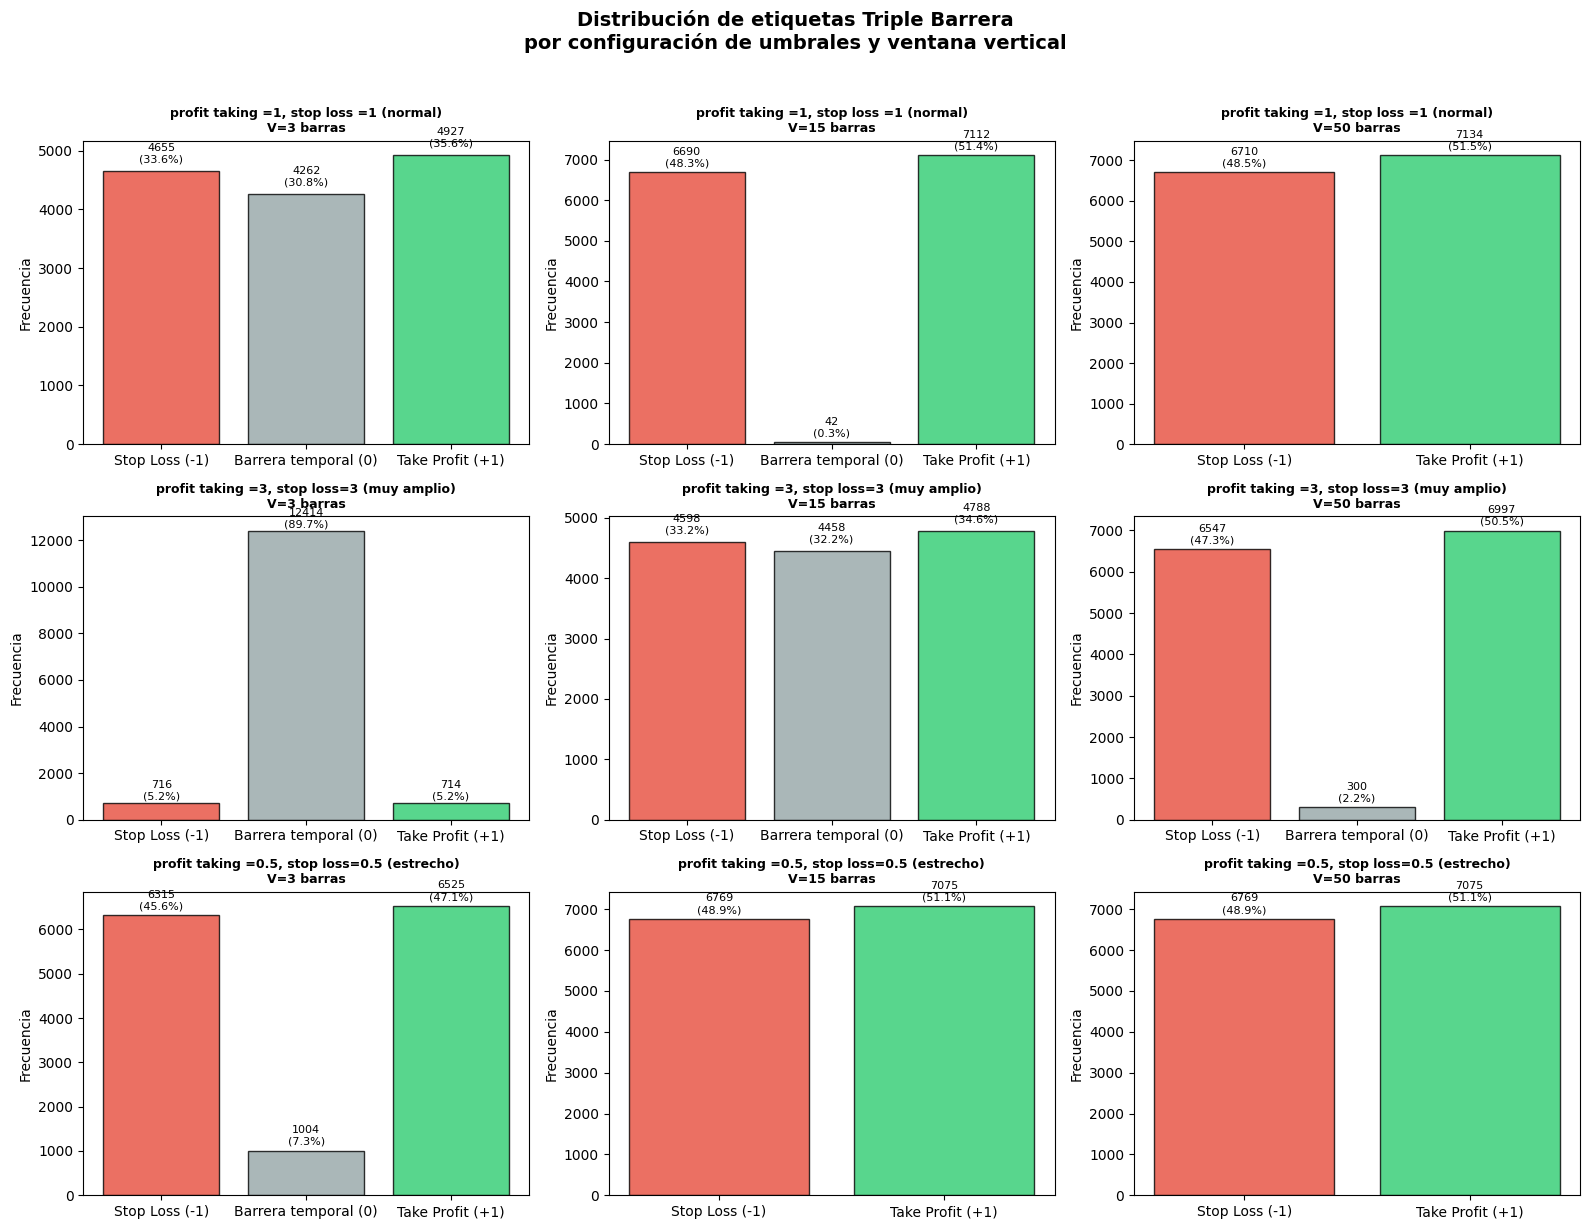

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

keys = list(all_results.keys())
colors_map = {-1: "#e74c3c", 0: "#95a5a6", 1: "#2ecc71"}
label_names = {-1: "Stop Loss (-1)", 0: "Barrera temporal (0)", 1: "Take Profit (+1)"}

for idx, key in enumerate(keys):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    bins = all_results[key]
    counts = bins["label"].value_counts().sort_index()

    bar_colors = [colors_map.get(k, "gray") for k in counts.index]
    bar_labels = [label_names.get(k, str(k)) for k in counts.index]

    ax.bar(bar_labels, counts.values, color=bar_colors, alpha=0.8, edgecolor="black")
    ax.set_title(key, fontsize=9, fontweight="bold")
    ax.set_ylabel("Frecuencia")

    total = counts.sum()
    for i, (lab, val) in enumerate(zip(bar_labels, counts.values)):
        ax.text(i, val + total * 0.01, f"{val}\n({val/total:.1%})",
                ha="center", fontsize=8)

plt.suptitle("Distribución de etiquetas Triple Barrera\npor configuración de umbrales y ventana vertical",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Observaciones sobre el etiquetado Triple Barrera (Triple Barrier Method)

Se analizan las distribuciones de las tres etiquetas (`-1` Stop Loss, `1` Take Profit, y `0` Expiración Temporal) obtenidas al cruzar distintas exigencias de volatilidad con distintos límites de tiempo (ventana V).

**1. Efecto de la exigencia del precio (umbrales pt y sl):**
- **Umbrales bajos (pt=0.5, sl=0.5):** Al pedirle al precio un movimiento direccional muy pequeño (media desviación), las barreras horizontales se alcanzan casi de inmediato. Esto provoca que el reloj prácticamente nunca llegue a cero (la clase temporal `0` desaparece).
- **Umbrales extremos (pt=3, sl=3):** Al exigir un movimiento enorme (tres desviaciones), el precio es matemáticamente incapaz de alcanzar la meta antes de que se agote el tiempo, provocando que la inmensa mayoría de las operaciones expiren y se etiqueten como clase `0` (ver panel intermedio izquierdo).

**2. Efecto del límite temporal (Ventana Vertical V):**
- **Ventanas muy cortas (V=3):** Fuerzan al precio a hacer movimientos bruscos en apenas 15 minutos. Como esto es raro, la barrera temporal "corta" la operación prematuramente y dispara masivamente la etiqueta `0`.
- **Ventanas largas (V=50):** Dan al precio más de 4 horas para oscilar libremente. En un activo hiper-volátil como BTC, este tiempo es más que suficiente para acabar cruzando la volatilidad estándar de 1 o 2 desviaciones en cualquier dirección, reduciendo la clase temporal a cero.

**Implicación práctica:** 
En los modelos de Machine Learning Financiero, el etiquetado no debe ser estático ni elegido al azar. Hemos demostrado empíricamente cómo el riesgo paramétrico de la temporalidad reduce drásticamente las oportunidades de TP/SL. Para entrenar un modelo que aprenda cuándo operar y cuándo quedarse quieto (clase `0`), la parametrización ideal en criptomonedas requiere estrechar agresivamente la ventana vertical temporal frente a la amplitud de la volatilidad esperada.


## 6. Validación cruzada Purged K-Fold

Se implementa la técnica de **Purged K-Fold Cross-Validation** . En datos financieros, la validación cruzada estándar (K-Fold) puede producir *data leakage* debido a la dependencia temporal entre observaciones:

- Las observaciones del conjunto de entrenamiento que están temporalmente cerca del conjunto de test pueden contener información que se solapa con las del test.
- Este solapamiento infla artificialmente las métricas de rendimiento del modelo.

### Solución: Purging y Embargo

1. **Purging:** Se eliminan del conjunto de entrenamiento las observaciones cuyo período de validez se solapa con alguna observación del conjunto de test.
2. **Embargo:** Se añade un margen de seguridad adicional eliminando observaciones del entrenamiento inmediatamente posteriores al conjunto de test, para prevenir la filtración por efectos rezagados.

Se compara visualmente la partición estándar K-Fold con la Purged K-Fold, mostrando las zonas de entrenamiento, test y purgado/embargo.

In [43]:
# Purged K-Fold CV
from sklearn.model_selection import KFold

class PurgedKFold:
    """Implementación de Purged K-Fold Cross-Validation con embargo."""
    def __init__(self, n_splits=5, t1=None, pct_embargo=0.0):
        self.n_splits = n_splits
        self.t1 = t1          # Serie con el índice de fin del evento para cada observación
        self.pct_embargo = pct_embargo

    def split(self, X):
        """Se generan los índices de train/test con purging y embargo."""
        n = len(X)
        indices = np.arange(n)
        embargo = int(n * self.pct_embargo)

        # Se divide en K folds contiguos
        fold_size = n // self.n_splits
        folds = []
        for i in range(self.n_splits):
            start = i * fold_size
            end = start + fold_size if i < self.n_splits - 1 else n
            folds.append(indices[start:end])

        for i in range(self.n_splits):
            test_idx = folds[i]
            test_start = test_idx[0]
            test_end = test_idx[-1]

            train_idx = []
            for j in indices:
                if j in test_idx:
                    continue
                # si el evento j tiene un t1 que cae dentro del rango del test
                if self.t1 is not None:
                    t1_j = int(self.t1.iloc[j]) if j < len(self.t1) else j
                    if t1_j >= test_start and j < test_start:
                        continue
                #  si la observación está en la zona de embargo tras el test
                if embargo > 0 and j > test_end and j <= test_end + embargo:
                    continue
                train_idx.append(j)

            yield np.array(train_idx), test_idx


def _contiguous_ranges(arr):
    """Se identifican rangos contiguos en un array de índices."""
    if len(arr) == 0:
        return
    start = arr[0]
    end = arr[0]
    for v in arr[1:]:
        if v == end + 1:
            end = v
        else:
            yield start, end + 1
            start = v
            end = v
    yield start, end + 1



first_key = list(all_results.keys())[0]
sample_bins = all_results[first_key]
t1_series = sample_bins["t1"]
n_vis = min(len(sample_bins), 2000)  # Se limita para visualización
X_vals = np.arange(n_vis)

print(f"Se utilizan {n_vis} observaciones para la demostración visual de Purged K-Fold.")
print(f"Datos del etiquetado Triple Barrera (config: {first_key.split(chr(10))[0]})")


Se utilizan 2000 observaciones para la demostración visual de Purged K-Fold.
Datos del etiquetado Triple Barrera (config: profit taking =1, stop loss =1 (normal))


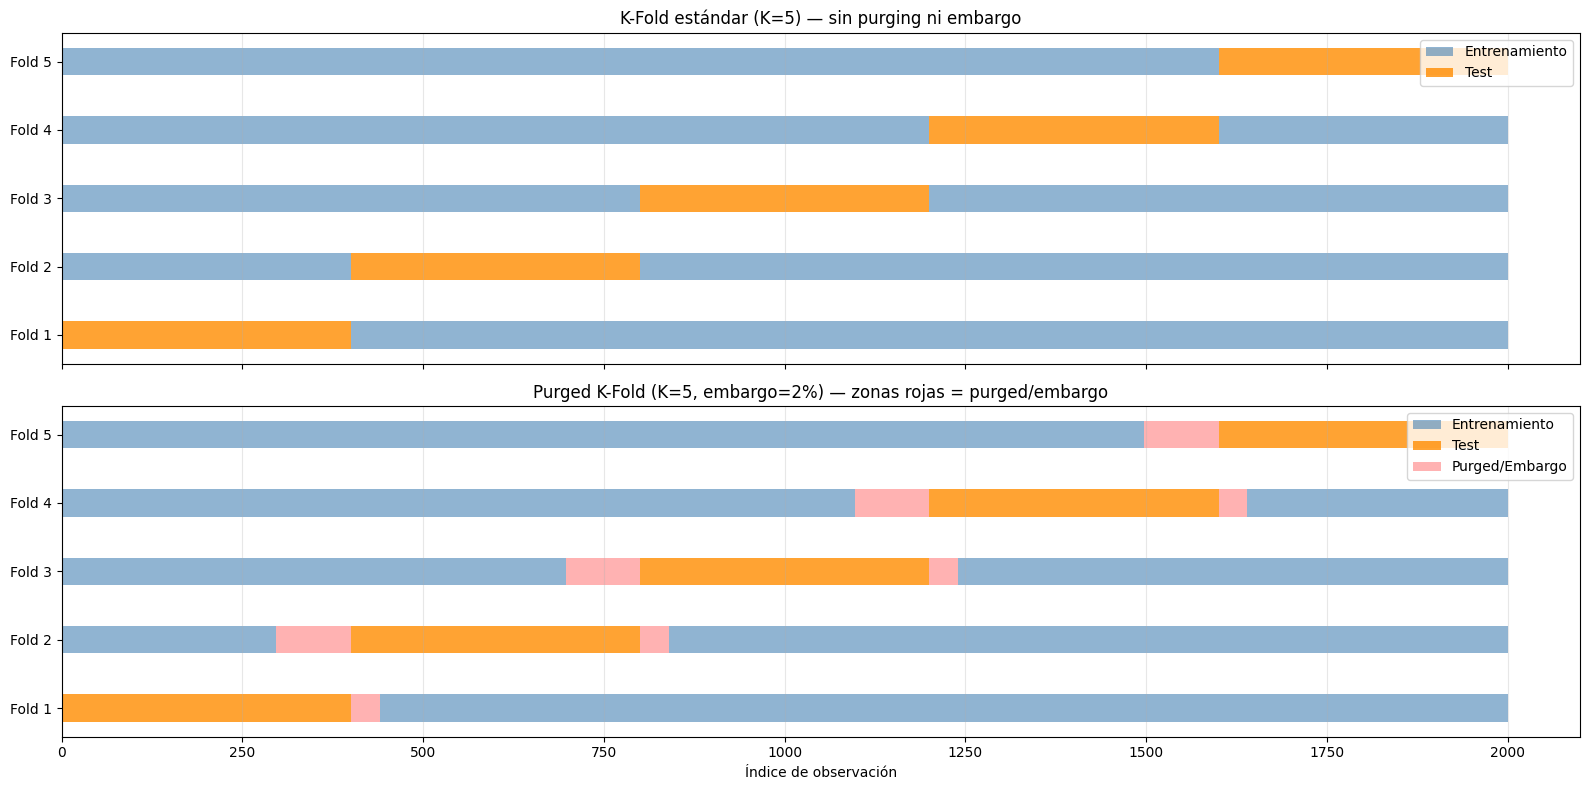

In [45]:
# comparación K-Fold estándar vs Purged K-Fold
from matplotlib.patches import Patch

k_vis = 5

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

#  Panel 1: K-Fold estándar 
ax = axes[0]
kf = KFold(n_splits=k_vis, shuffle=False)
for fold_i, (train_idx, test_idx) in enumerate(kf.split(X_vals)):
    for start, end in _contiguous_ranges(train_idx):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="steelblue", alpha=0.6)
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4, color="darkorange", alpha=0.8)

ax.set_yticks(range(k_vis))
ax.set_yticklabels([f"Fold {i+1}" for i in range(k_vis)])
ax.set_title(f"K-Fold estándar (K={k_vis}) — sin purging ni embargo", fontsize=12)
legend_elements = [Patch(facecolor="steelblue", alpha=0.6, label="Entrenamiento"),
                   Patch(facecolor="darkorange", alpha=0.8, label="Test")]
ax.legend(handles=legend_elements, loc="upper right")
ax.grid(True, axis="x", alpha=0.3)

#  Panel 2: Purged K-Fold con embargo 
ax = axes[1]
pct_emb_vis = 0.02
pkf = PurgedKFold(n_splits=k_vis, t1=t1_series, pct_embargo=pct_emb_vis)

for fold_i, (train_idx, test_idx) in enumerate(pkf.split(X_vals)):
    for start, end in _contiguous_ranges(train_idx):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="steelblue", alpha=0.6)
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4, color="darkorange", alpha=0.8)
    # Se colorean las zonas purgadas/embargadas
    all_used = set(train_idx) | set(test_idx)
    purged = sorted(set(range(n_vis)) - all_used)
    for start, end in _contiguous_ranges(np.array(purged)):
        ax.barh(fold_i, end - start, left=start, height=0.4, color="red", alpha=0.3)

ax.set_yticks(range(k_vis))
ax.set_yticklabels([f"Fold {i+1}" for i in range(k_vis)])
ax.set_xlabel("Índice de observación")
ax.set_title(f"Purged K-Fold (K={k_vis}, embargo={pct_emb_vis:.0%}) — zonas rojas = purged/embargo", fontsize=12)
legend_elements2 = [Patch(facecolor="steelblue", alpha=0.6, label="Entrenamiento"),
                    Patch(facecolor="darkorange", alpha=0.8, label="Test"),
                    Patch(facecolor="red", alpha=0.3, label="Purged/Embargo")]
ax.legend(handles=legend_elements2, loc="upper right")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


### Observaciones sobre la Validación Cruzada: Purging y Embargo (López de Prado)

La evaluación de modelos de Machine Learning (ML) en series temporales financieras requiere técnicas especializadas para evitar la filtración de información futura (*Data Leakage*), un problema derivado de la fuerte autocorrelación de los precios y de la resolución diferida de las etiquetas.

**K-Fold estándar vs Purged K-Fold:**
- El **K-Fold estándar (Gráfico Superior)** asume que las observaciones son independientes (IID). Al aplicar el Triple Barrier Method, la etiqueta del instante $t$ se decide analizando el futuro hasta el instante $t+V$. Si el conjunto de Test en K-Fold comienza justo en $t+1$, el modelo de Entrenamiento dispondrá de información que cronológicamente pertenece al Test, inflando artificialmente las métricas de evaluación.
- El **Purged K-Fold (Gráfico Inferior)** soluciona este solapamiento mediante la técnica de "Purga" (zonas rosas). El algoritmo extirpa físicamente del Training Set todas las filas cuyo horizonte temporal de resolución (la barrera vertical $V$) se introduzca o pise el límite temporal del conjunto de Test. De esta forma, garantiza un examen en un entorno 100% virgen (Out-of-Sample real).

**Efecto del Embargo:**
- El Purging limpia el solapamiento directo, pero el **Embargo** añade un escudo adicional *después* del bloque de Test. Al imponer un Embargo (ej. 2-5%), eliminamos las observaciones de Entrenamiento inmediatamente posteriores al Test, previniendo que el modelo deduzca lo ocurrido en el Test a partir de los "ecos" estadísticos o retornos rezagados (*lagged effects*).

**Efecto de K:**
- Un número elevado de divisiones ($K$ grande) reduce la varianza de la evaluación y genera bloques de Test más pequeños. Sin embargo, en series temporales de alta resolución, obliga a ejecutar el proceso de Purging y Embargo en demasiadas fronteras, destruyendo un porcentaje masivo de datos de entrenamiento valiosos (barras rosas devorando las barras azules). Es necesario equilibrar la robustez estadística con la preservación del volumen de datos históricos.

**Implicación Práctica en Algorithmic Trading:** 
Al combinar el etiquetado por Triple Barrera con el fraccionamiento Purged K-Fold, aseguramos que el entrenamiento del modelo de ML sea extremadamente conservador, realista y matemáticamente aislado. Un modelo que consiga precisión predictiva bajo este estricto régimen de pruebas tiene métricas fiables y mayores probabilidades de sobrevivir íntegro en la transición a operativa *Live Trading*.
